# statistical analysis of likelihood maps


In [1]:
import retinoto_py as fovea
subset_factor = 400
subset_factor = 50
subset_factor = 200
args = fovea.Params(do_fovea=True, batch_size=1, subset_factor=subset_factor)
args

Params(batch_size=1, num_workers=4, prefetch_factor=0, image_size=224, grid_size_ecc=161, grid_size_ang=309, do_mask=False, do_fovea=True, use_hexagonal_grid=True, rs_min=-3.5, rs_max=0.7, angle_start=-5.235987755982989, angle_margin=0.010166966516471823, mode='bilinear', padding_mode='zeros', model_name='convnext_base', num_epochs=100, subset_factor=200, optimizer_name='adamw', loss_name='CrossEntropyLoss', base_lr=1e-06, final_lr=1e-09, num_warmup_epochs=20, delta1=0.3, delta2=0.002, weight_decay=0.0001, label_smoothing=0.0005, do_full_training=True, do_augment=True, augment_proba=0.85, stochastic_depth_prob=0.6, seed=1998, shuffle=True, verbose=False)

In [2]:
# model_filename = args.data_cache /  f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'
# model = fovea.load_model(args, model_filename=model_filename)
# model_filename

In [3]:
npz_filename = args.data_cache / '42_likelihood_maps.npz'
# %rm {npz_filename}  # FORCING RECOMPUTE

In [ ]:
resolution = (100, 100)
resolution = (30, 30)
resolution = (7, 7)
resolution = (25, 25)
# resolution = (21, 21)

N_fixations = fovea.np.prod(resolution)

size_ratios = fovea.np.linspace(0.1, 0.9, 9)
size_ratios = fovea.np.linspace(0.1, 0.9, 15)
size_ratios = fovea.np.linspace(0.1, 1.3, 15)
size_ratios = fovea.np.linspace(0.8, 1.3, 7)

angles = [0, 45, 90, 135, 180]
angles = [0, 45, 90, 135, 180, 225, 270, 315]
# size_ratios = fovea.np.linspace(0.1, 0.9, 3)
# angles=[0, 60, 120]
angles = [0, 90, 180, 270]

all_datasets = fovea.params.all_datasets
all_datasets = ['bbox']
do_foveas = [True, False]
do_foveas = [True]

In [5]:
# from torchvision.transforms.functional import InterpolationMode, resize
for do_fovea in do_foveas:
    for dataset in all_datasets:
        args = fovea.Params(do_mask=not(do_fovea), do_fovea=do_fovea, 
                            batch_size=1, subset_factor=subset_factor)
        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'

        if npz_filename.exists():
            with fovea.np.load(npz_filename) as data:
                likelihood_maps_label = data['likelihood_maps_label']
                likelihood_maps_label_max = data['likelihood_maps_label_max']
                likelihood_maps_max = data['likelihood_maps_max']
                size_ratio_max = data['size_ratio_max']
        else:

            print('computing ', npz_filename)
            VAL_DATA_DIR = args.DATAROOT / f'Imagenet_{dataset}' / 'val'
            val_dataset = fovea.get_dataset(args, VAL_DATA_DIR, do_full_preprocess=False)
            val_loader = fovea.get_loader(args, val_dataset)

            if do_fovea:
                model_filename = args.data_cache /  f'32_fovea_model_name={args.model_name}_dataset=bbox.pth'
            else:
                model_filename = args.data_cache /  f'21_model_name={args.model_name}_dataset=full.pth'
            model = fovea.load_model(args, model_filename=model_filename)

            likelihood_maps_label = fovea.np.empty((resolution[0], resolution[1], 0))
            likelihood_maps_label_max = fovea.np.empty((resolution[0], resolution[1], 0))
            likelihood_maps_max = fovea.np.empty((resolution[0], resolution[1], 0))
            size_ratio_max = []
            for _, (image, true_idx) in fovea.tqdm(enumerate(val_loader), total=len(val_loader.dataset)):
                # image, true_idx = image.to(args.device), true_idx.to(args.device)
                image = image.to('cpu')
                image = image.squeeze(0)

                image = fovea.squarify(image)
                three, H, W = image.shape
                assert H == W, f"aspect ratio should be one but {H=} and {W=} "

                pos_H, pos_W = fovea.get_positions(H, W, resolution=resolution, do_hex=False)

                try:
                    proba_label, proba_label_maximum, proba_max, proba_label_max = None, 0., None, None
                    size_ratio_max_ = size_ratios[0]
                    for size_ratio in size_ratios:
                        for angle in angles:
                            probas = fovea.compute_likelihood_map(args, model, image, pos_H, pos_W, 
                                                                size_ratio=size_ratio, angle=angle, do_softmax=True)
                            probas = probas.cpu()
                            proba_label_ = probas[:, true_idx]

                            if proba_label_.max() > proba_label_maximum:
                                proba_label_maximum = proba_label_.max()
                                size_ratio_max_ = size_ratio

                            proba_max_, _ = probas.max(axis=-1)
                            if proba_max is None:
                                proba_max = proba_max_
                            else:
                                proba_max = fovea.torch.maximum(proba_max, proba_max_)

                            if proba_label_max is None:
                                proba_label_max = proba_label_
                            else:
                                proba_label_max = fovea.torch.maximum(proba_label_max, proba_label_)

                            if proba_label is None:
                                proba_label = proba_label_
                            else:
                                proba_label += proba_label_

                    proba_label = proba_label / len(size_ratios) / len(angles)
                    size_ratio_max.append(size_ratio_max_)

                    likelihood_maps_label_ = proba_label.cpu().numpy().reshape(resolution)
                    likelihood_maps_label = fovea.np.dstack((likelihood_maps_label, likelihood_maps_label_))

                    likelihood_maps_label_max_ = proba_label_max.cpu().numpy().reshape(resolution)
                    likelihood_maps_label_max = fovea.np.dstack((likelihood_maps_label_max, likelihood_maps_label_max_))
                    
                    likelihood_maps_max_ = proba_max.cpu().numpy().reshape(resolution)
                    likelihood_maps_max = fovea.np.dstack((likelihood_maps_max, likelihood_maps_max_))
                except Exception as e:
                    print(e)#, probas.shape, image.shape)

            fovea.np.savez(npz_filename, 
                likelihood_maps_max=likelihood_maps_max,
                likelihood_maps_label=likelihood_maps_label,
                likelihood_maps_label_max=likelihood_maps_label_max,
                size_ratio_max=fovea.np.array(size_ratio_max)
                )


In [6]:
size_ratio_max.shape, size_ratios.shape

((397,), (15,))

In [7]:
size_ratio_max.shape

(397,)

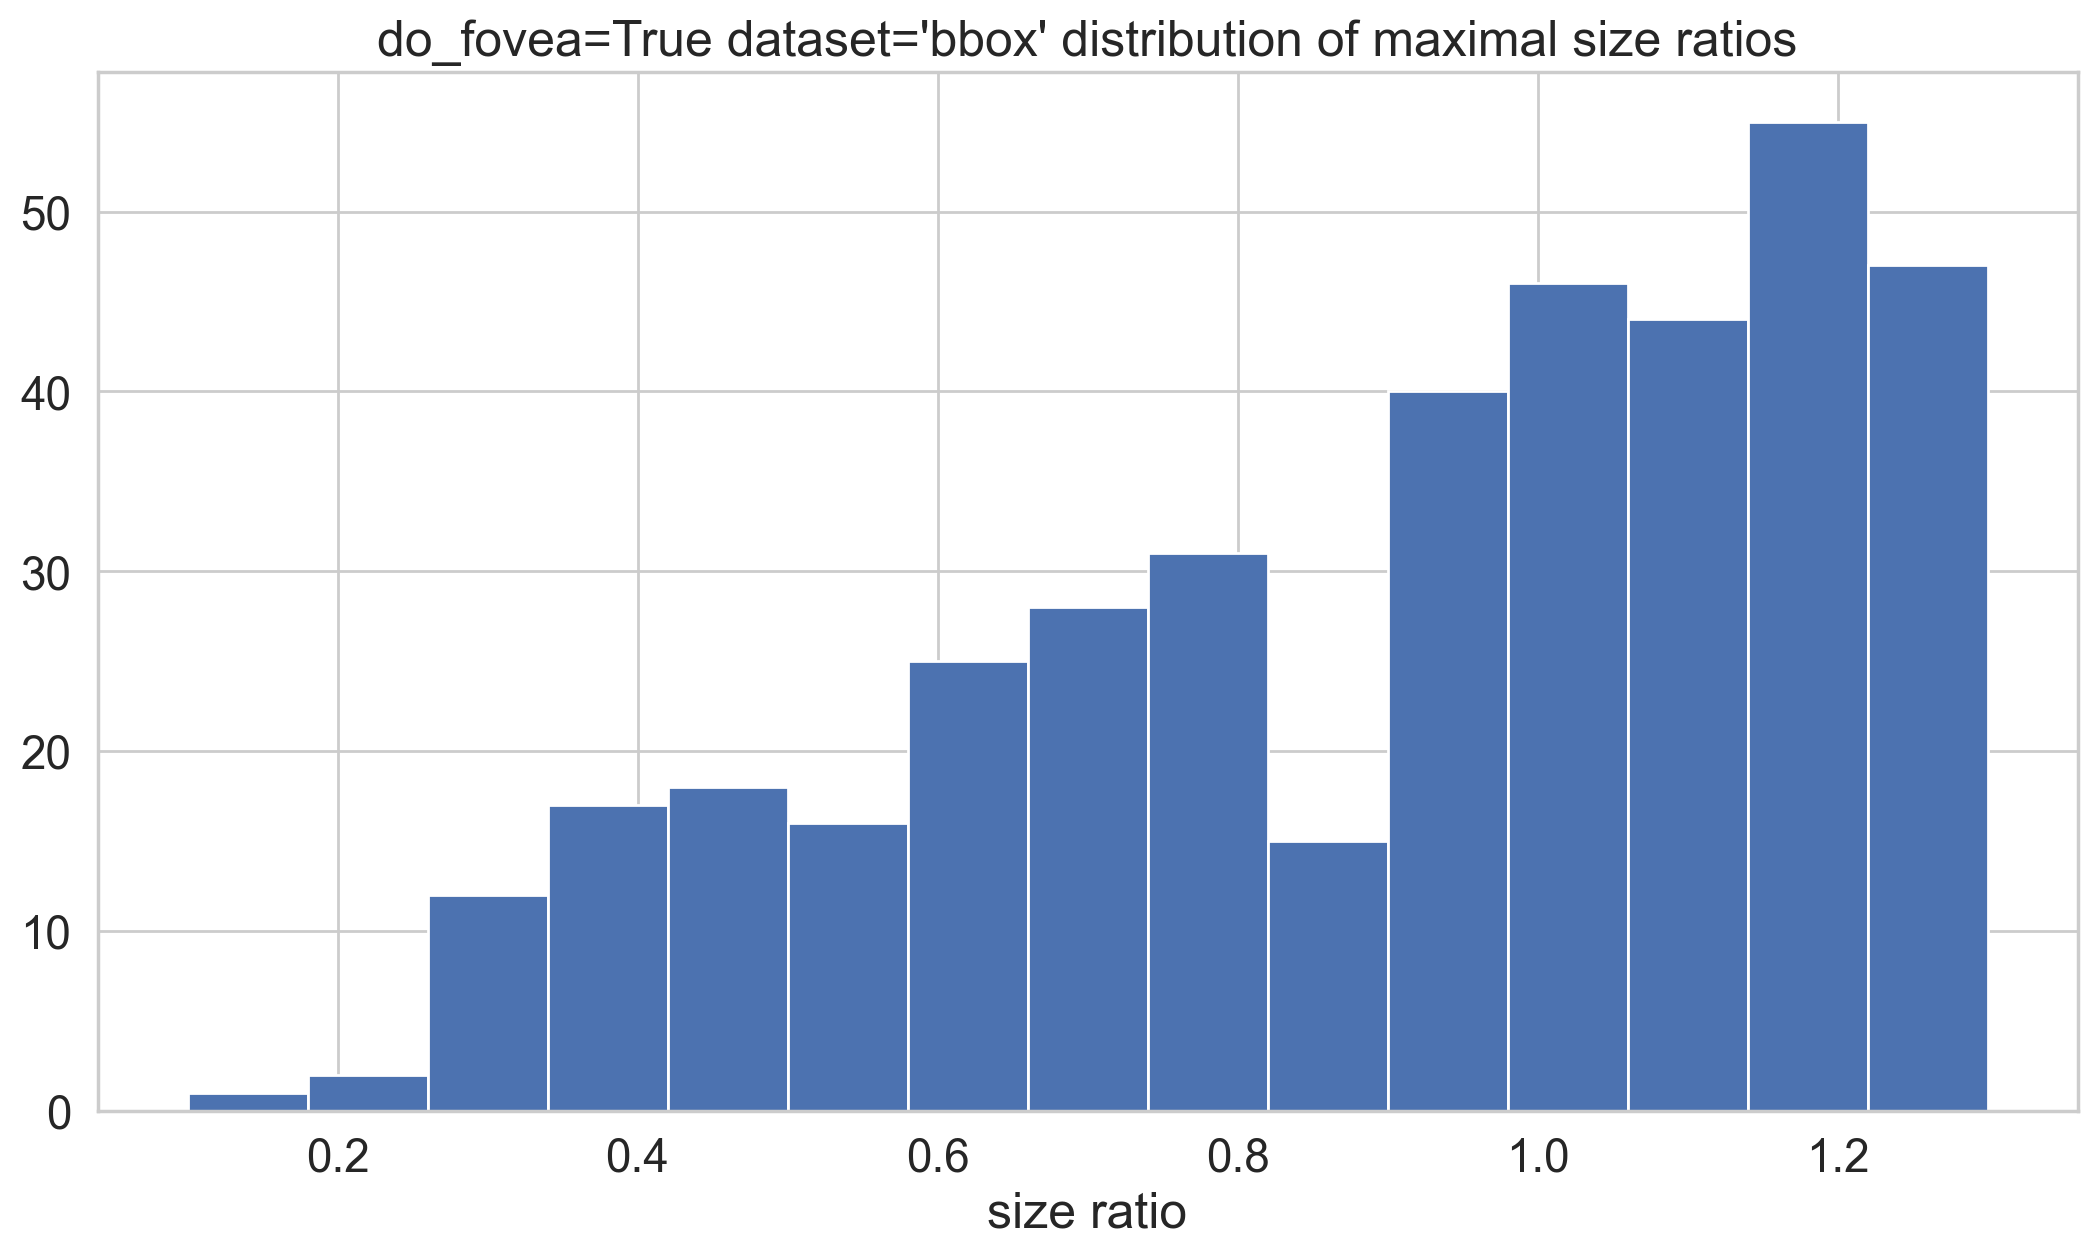

In [32]:
for do_fovea in do_foveas:
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']
            likelihood_maps_label_max = data['likelihood_maps_label_max']
            size_ratio_max = data['size_ratio_max']


        fig, ax = fovea.plt.subplots()
        ax.hist(size_ratio_max, bins=fovea.np.unique(size_ratio_max).size)
        ax.set(xlabel='size ratio', title=f'{do_fovea=} {dataset=} distribution of maximal size ratios')
        


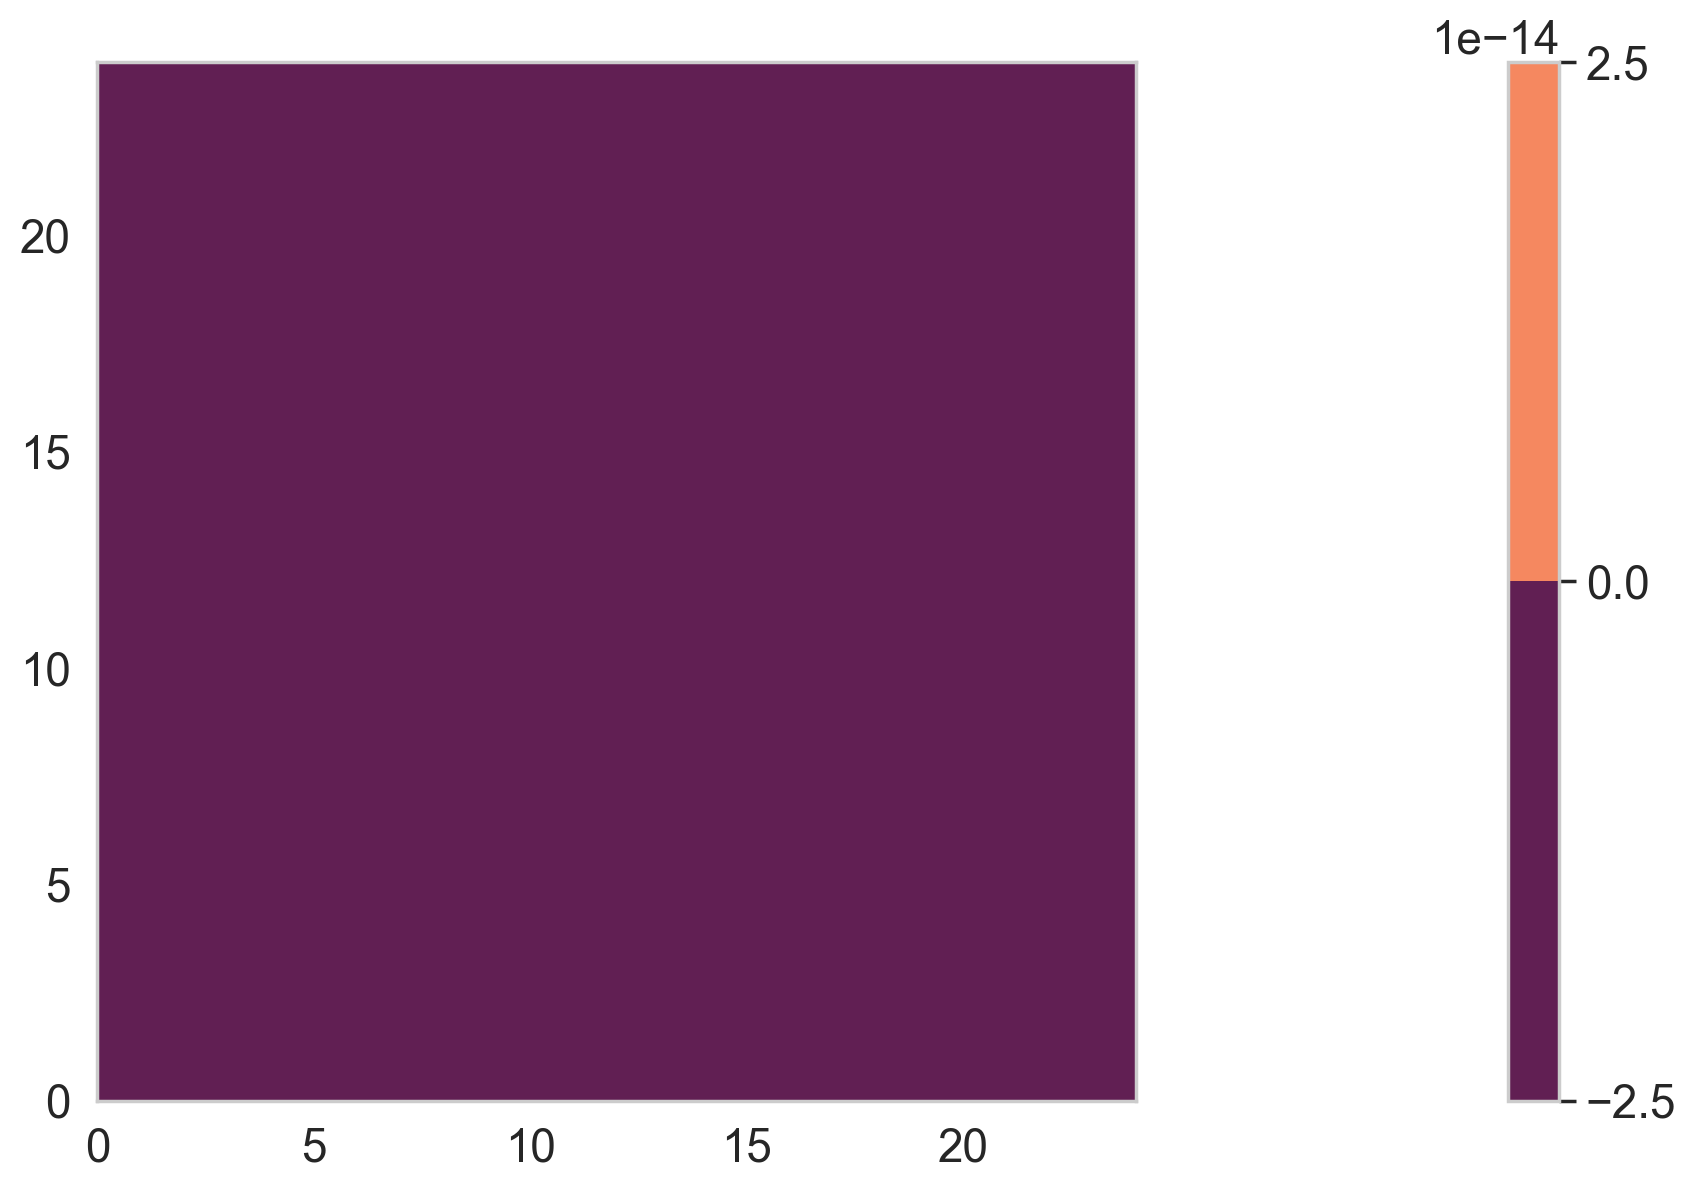

In [9]:
for do_fovea in do_foveas:
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']
            likelihood_maps_label_max = data['likelihood_maps_label_max']
            size_ratio_max = data['size_ratio_max']
    # TODO analyse if you get a better recognition outside the center
    correct_maps =  likelihood_maps_label == likelihood_maps_max
    fig, ax = fovea.plt.subplots()
    contour = ax.contourf(correct_maps.mean(axis=-1))
    fig.colorbar(contour, ax=ax)  # Add colorbar
    ax.axis('square')
    fig.set_facecolor(color='white')


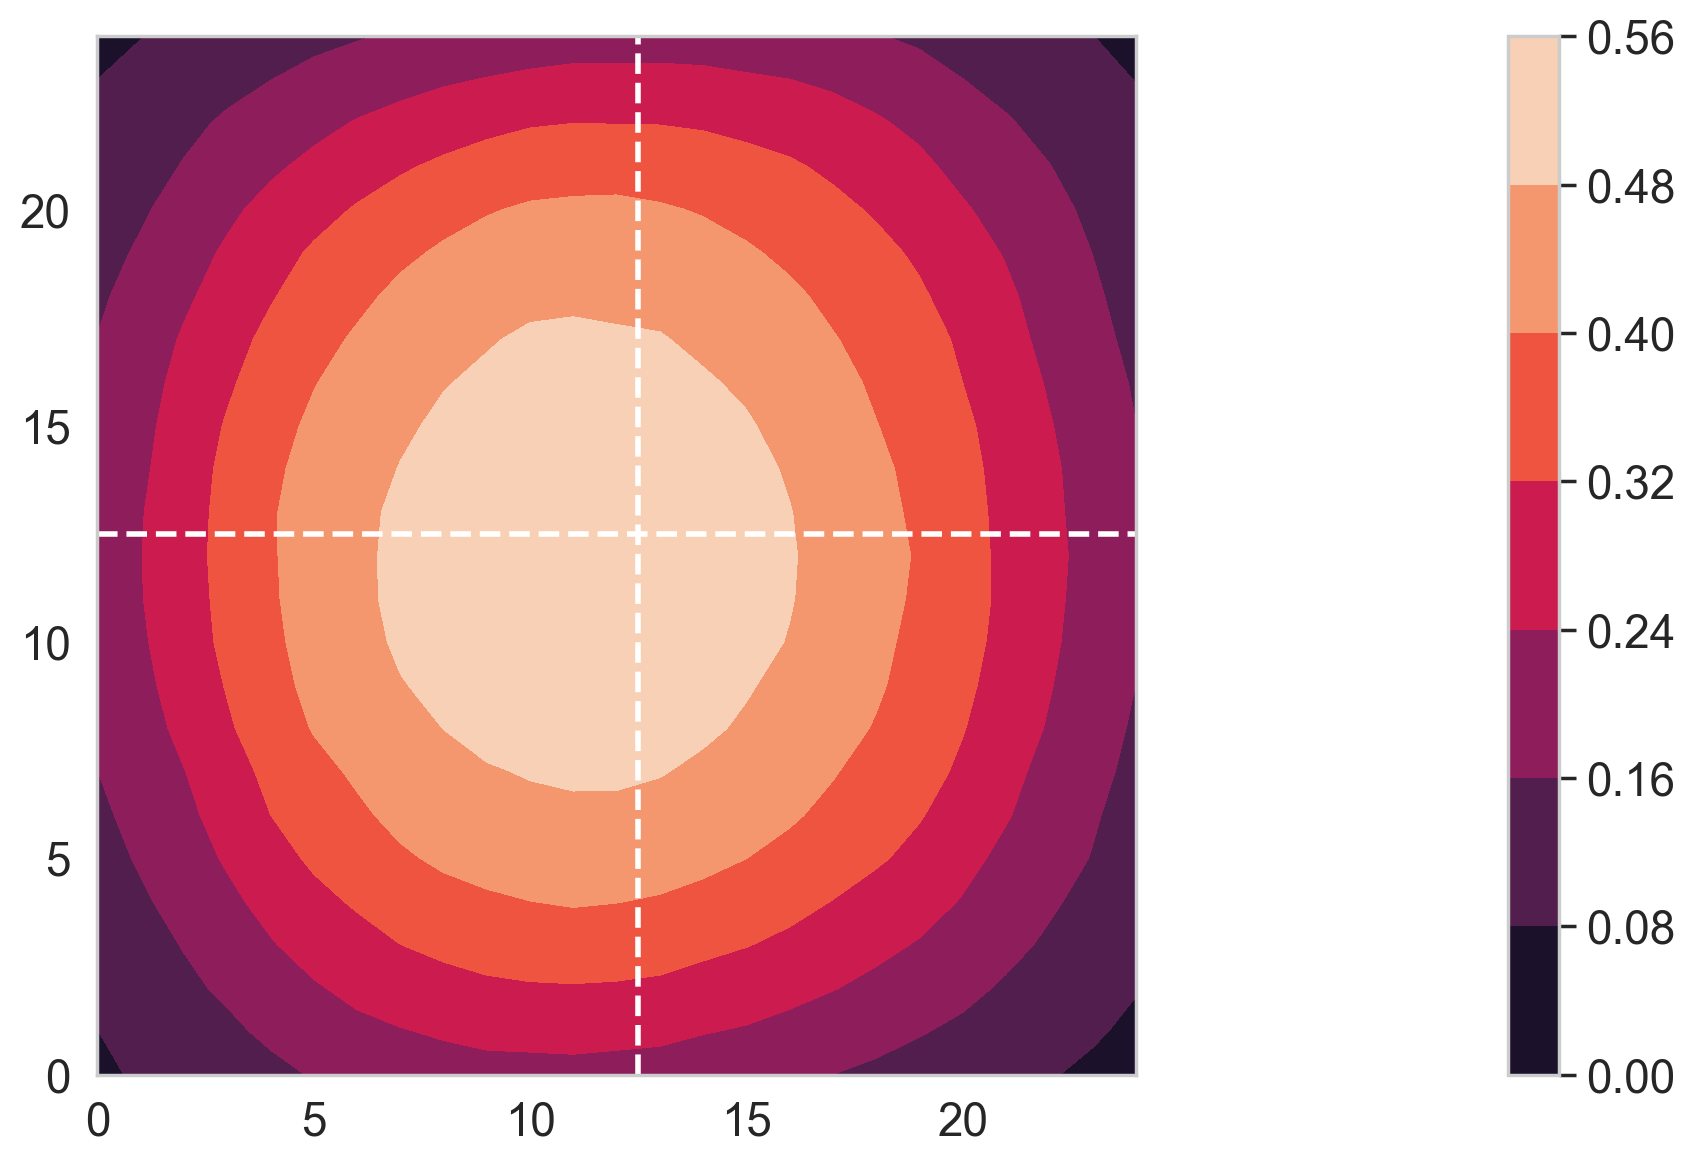

In [10]:
for do_fovea in do_foveas:
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']
            likelihood_maps_label_max = data['likelihood_maps_label_max']
            size_ratio_max = data['size_ratio_max']

        fig, ax = fovea.plt.subplots()
        contour = ax.contourf(likelihood_maps_label.mean(axis=-1))
        fig.colorbar(contour, ax=ax)  # Add colorbar
        ax.axis('square')
        mid_w = likelihood_maps_label.shape[1] / 2
        mid_h = likelihood_maps_label.shape[0] / 2
        ax.axvline(x=mid_w, color='white', linestyle='--', linewidth=2)
        ax.axhline(y=mid_h, color='white', linestyle='--', linewidth=2)

        fig.set_facecolor(color='white')


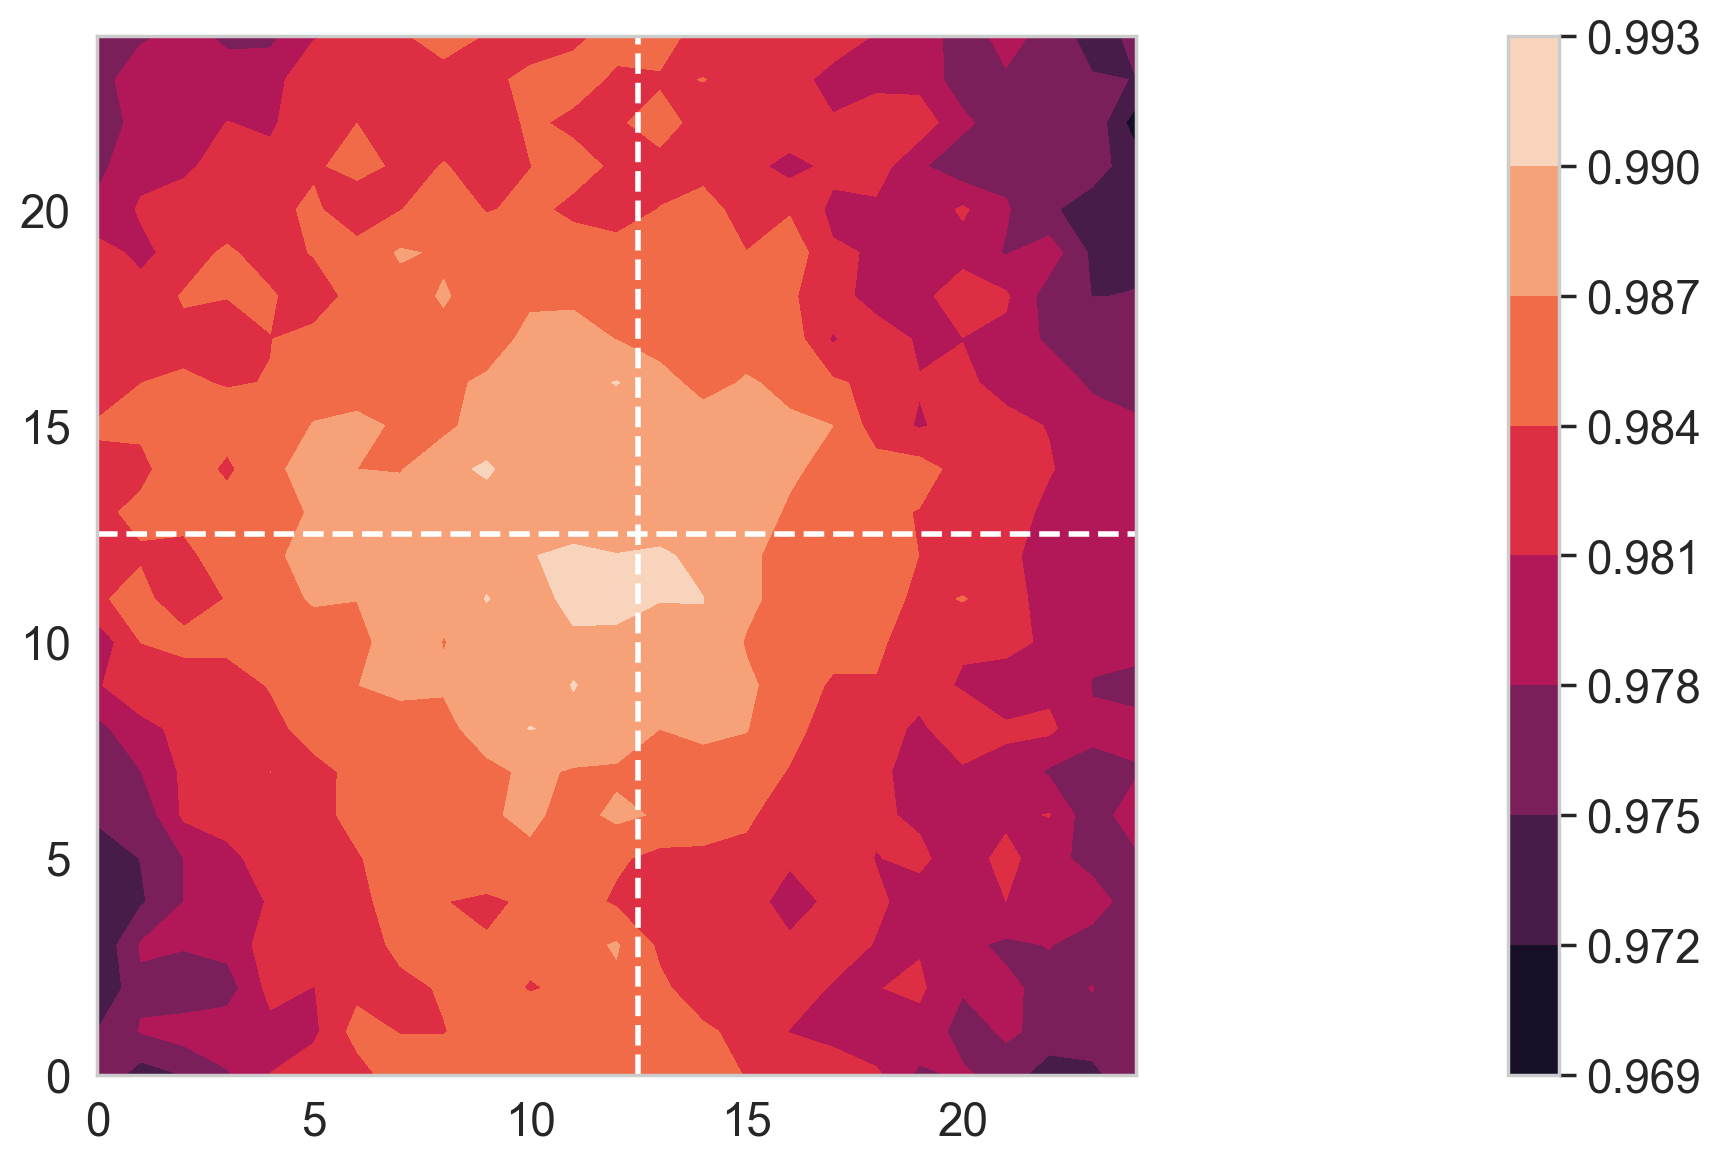

In [11]:
for do_fovea in do_foveas:
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']
            likelihood_maps_label_max = data['likelihood_maps_label_max']
            size_ratio_max = data['size_ratio_max']

        fig, ax = fovea.plt.subplots() 
        contour = ax.contourf(likelihood_maps_max.mean(axis=-1)) fig.colorbar(contour, ax=ax)  # Add colorbar ax.axis('square') ax.axvline(x=mid_w, color='white', linestyle='--', linewidth=2) ax.axhline(y=mid_h, color='white', linestyle='--', linewidth=2) fig.set_facecolor(color='white')
        # i_image = 2
        # proba = likelihood_maps[:, :, i_image]
        # proba.min(), proba.max()
        fig, ax = fovea.plt.subplots()
        contour = ax.contourf(likelihood_maps_label.mean(axis=-1))
        fig.colorbar(contour, ax=ax)  # Add colorbar
        ax.axis('square')
        ax.axvline(x=mid_w, color='white', linestyle='--', linewidth=2)
        ax.axhline(y=mid_h, color='white', linestyle='--', linewidth=2)
        fig.set_facecolor(color='white')
        accuracy = likelihood_maps_max.max(axis=(0, 1))
        fig, ax = fovea.plt.subplots()
        ax.hist(accuracy, bins=40)
        ax.set(xlabel='likelihood', title='distribution of maximal label likelihoods')
        accuracy = likelihood_maps_label_max.max(axis=(0, 1))
        fig, ax = fovea.plt.subplots()
        ax.hist(accuracy, bins=40)
        ax.set(xlabel='likelihood', title='distribution of maximal label likelihoods')
        accuracy = likelihood_maps_label.max(axis=(0, 1))
        fig, ax = fovea.plt.subplots()
        ax.hist(accuracy, bins=40)
        ax.set(xlabel='likelihood', title='distribution of maximal label likelihoods')

In [17]:
import pandas as pd
import numpy as np
pos_H, pos_W = fovea.get_positions(1, 1, resolution=resolution, do_hex=False)
pos_H.min(), pos_H.max(), pos_W.min(), pos_W.max(), pos_H.shape, likelihood_maps_label.shape

(np.float64(0.038461538461538464),
 np.float64(0.9615384615384616),
 np.float64(0.038461538461538464),
 np.float64(0.9615384615384616),
 (625,),
 (25, 25, 397))

In [18]:
# data = []
# for do_fovea in [True, False]:    
#     likelihood_maps = fovea.np.load(npy_filename)
#     data_= pd.DataFrame({
#         'horizontal position': pos_H,
#         'vertical position': pos_W,
#         'probas': likelihood_maps.mean(axis=-1).T.flatten(),
#         'retinotopy': 'foveated' if do_fovea else 'uniform' 
#     })
#     data.append(data_)
# combined_data = pd.concat(data, ignore_index=True)
# combined_data

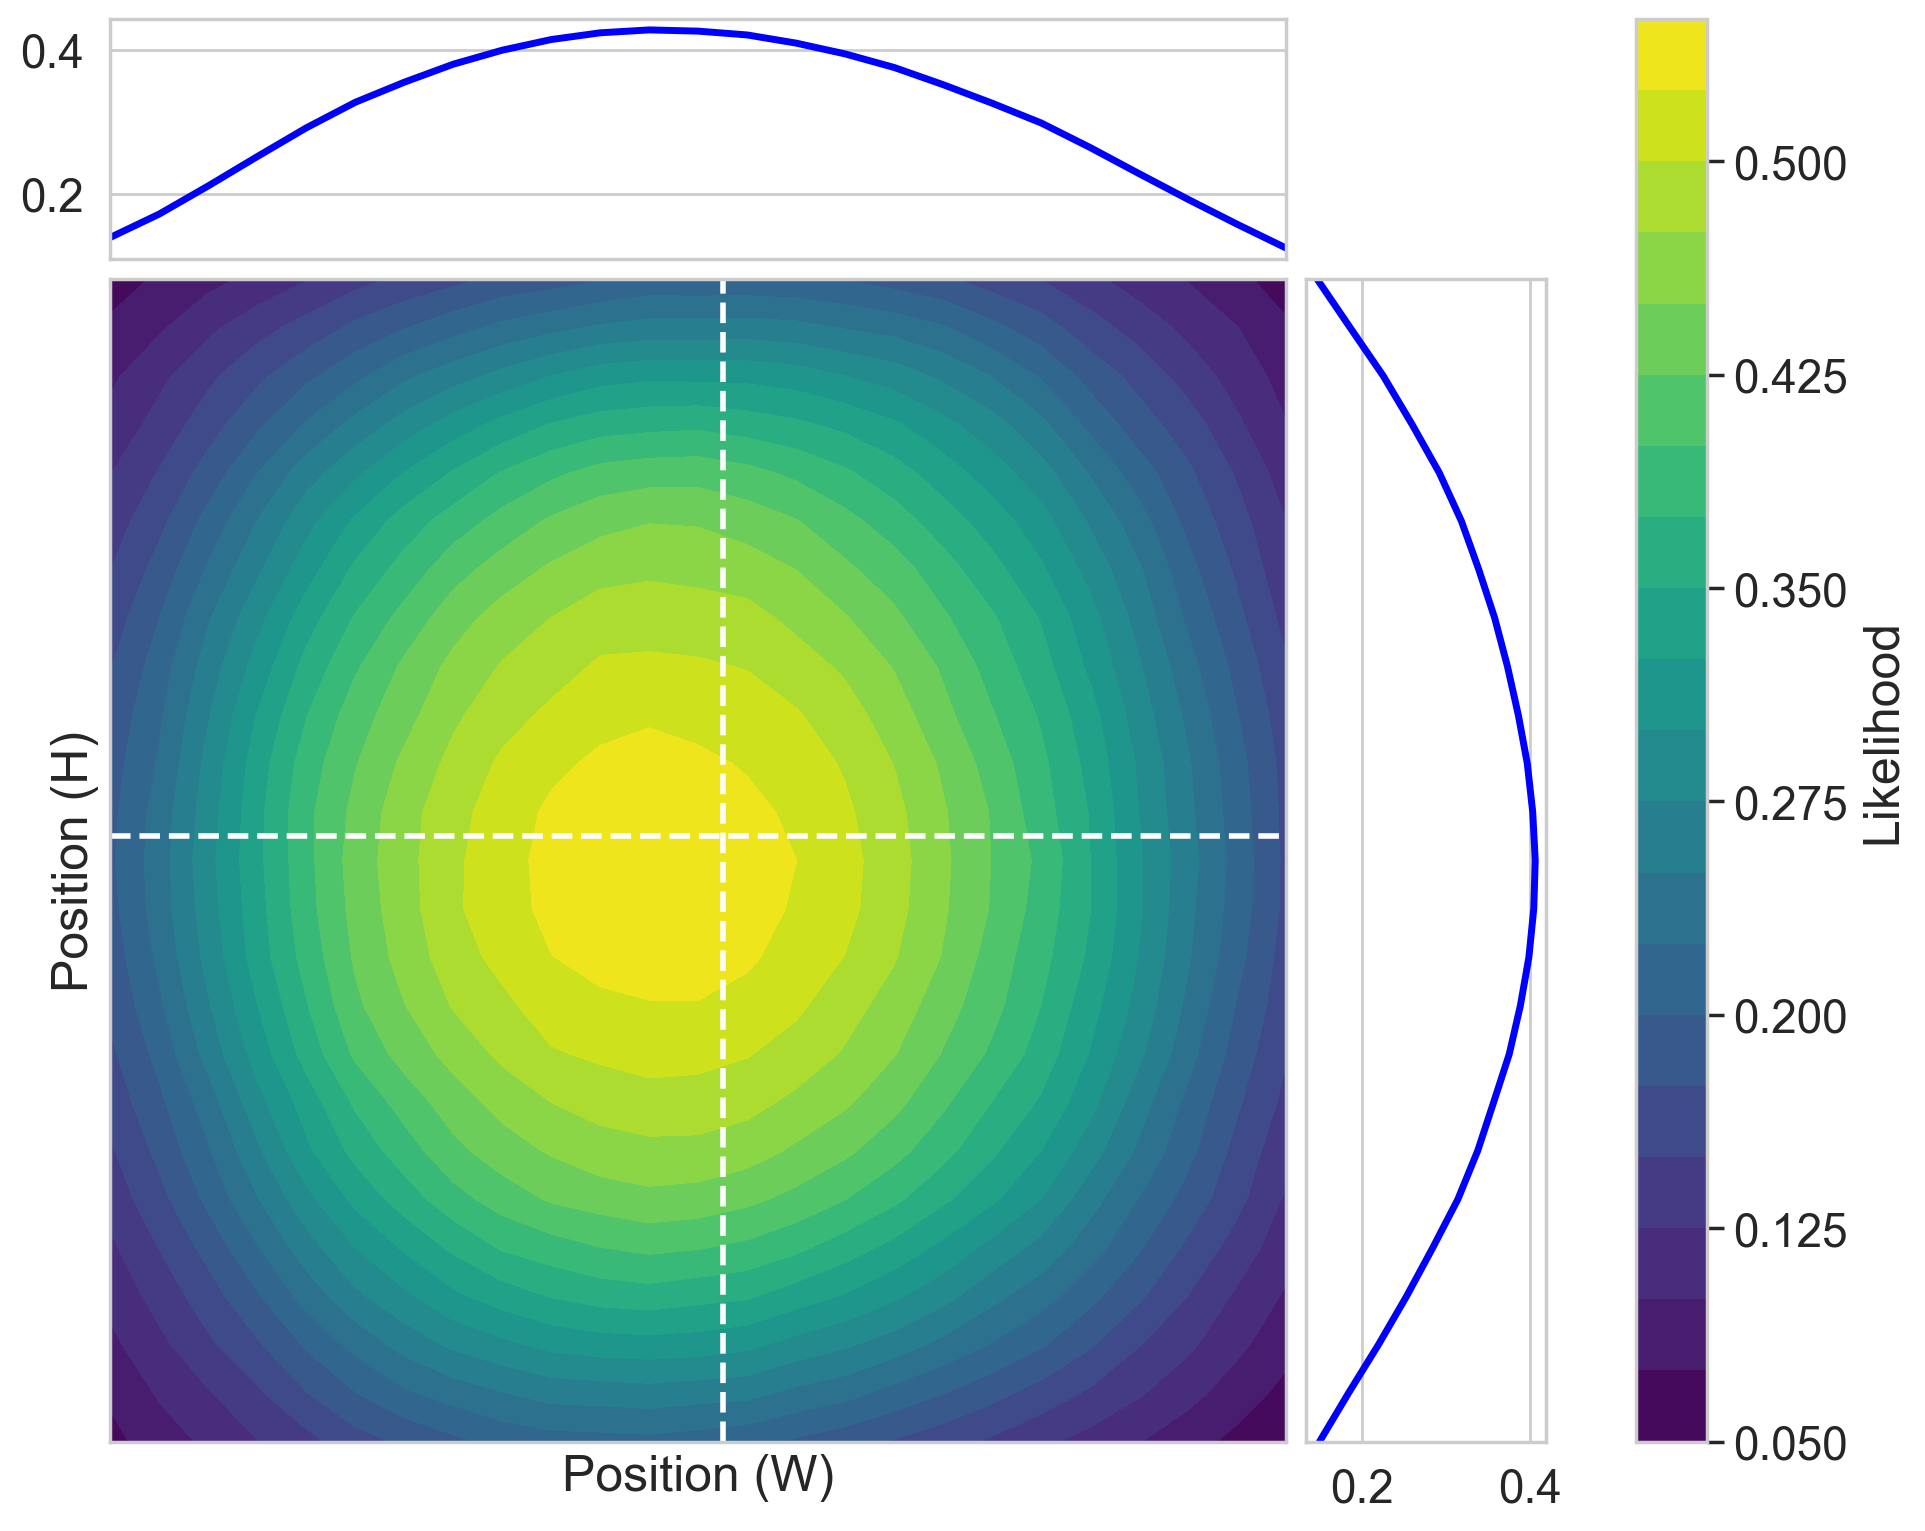

In [19]:

fig, axes = fovea.visualize_likelihood_map(likelihood_maps_label.mean(axis=-1))


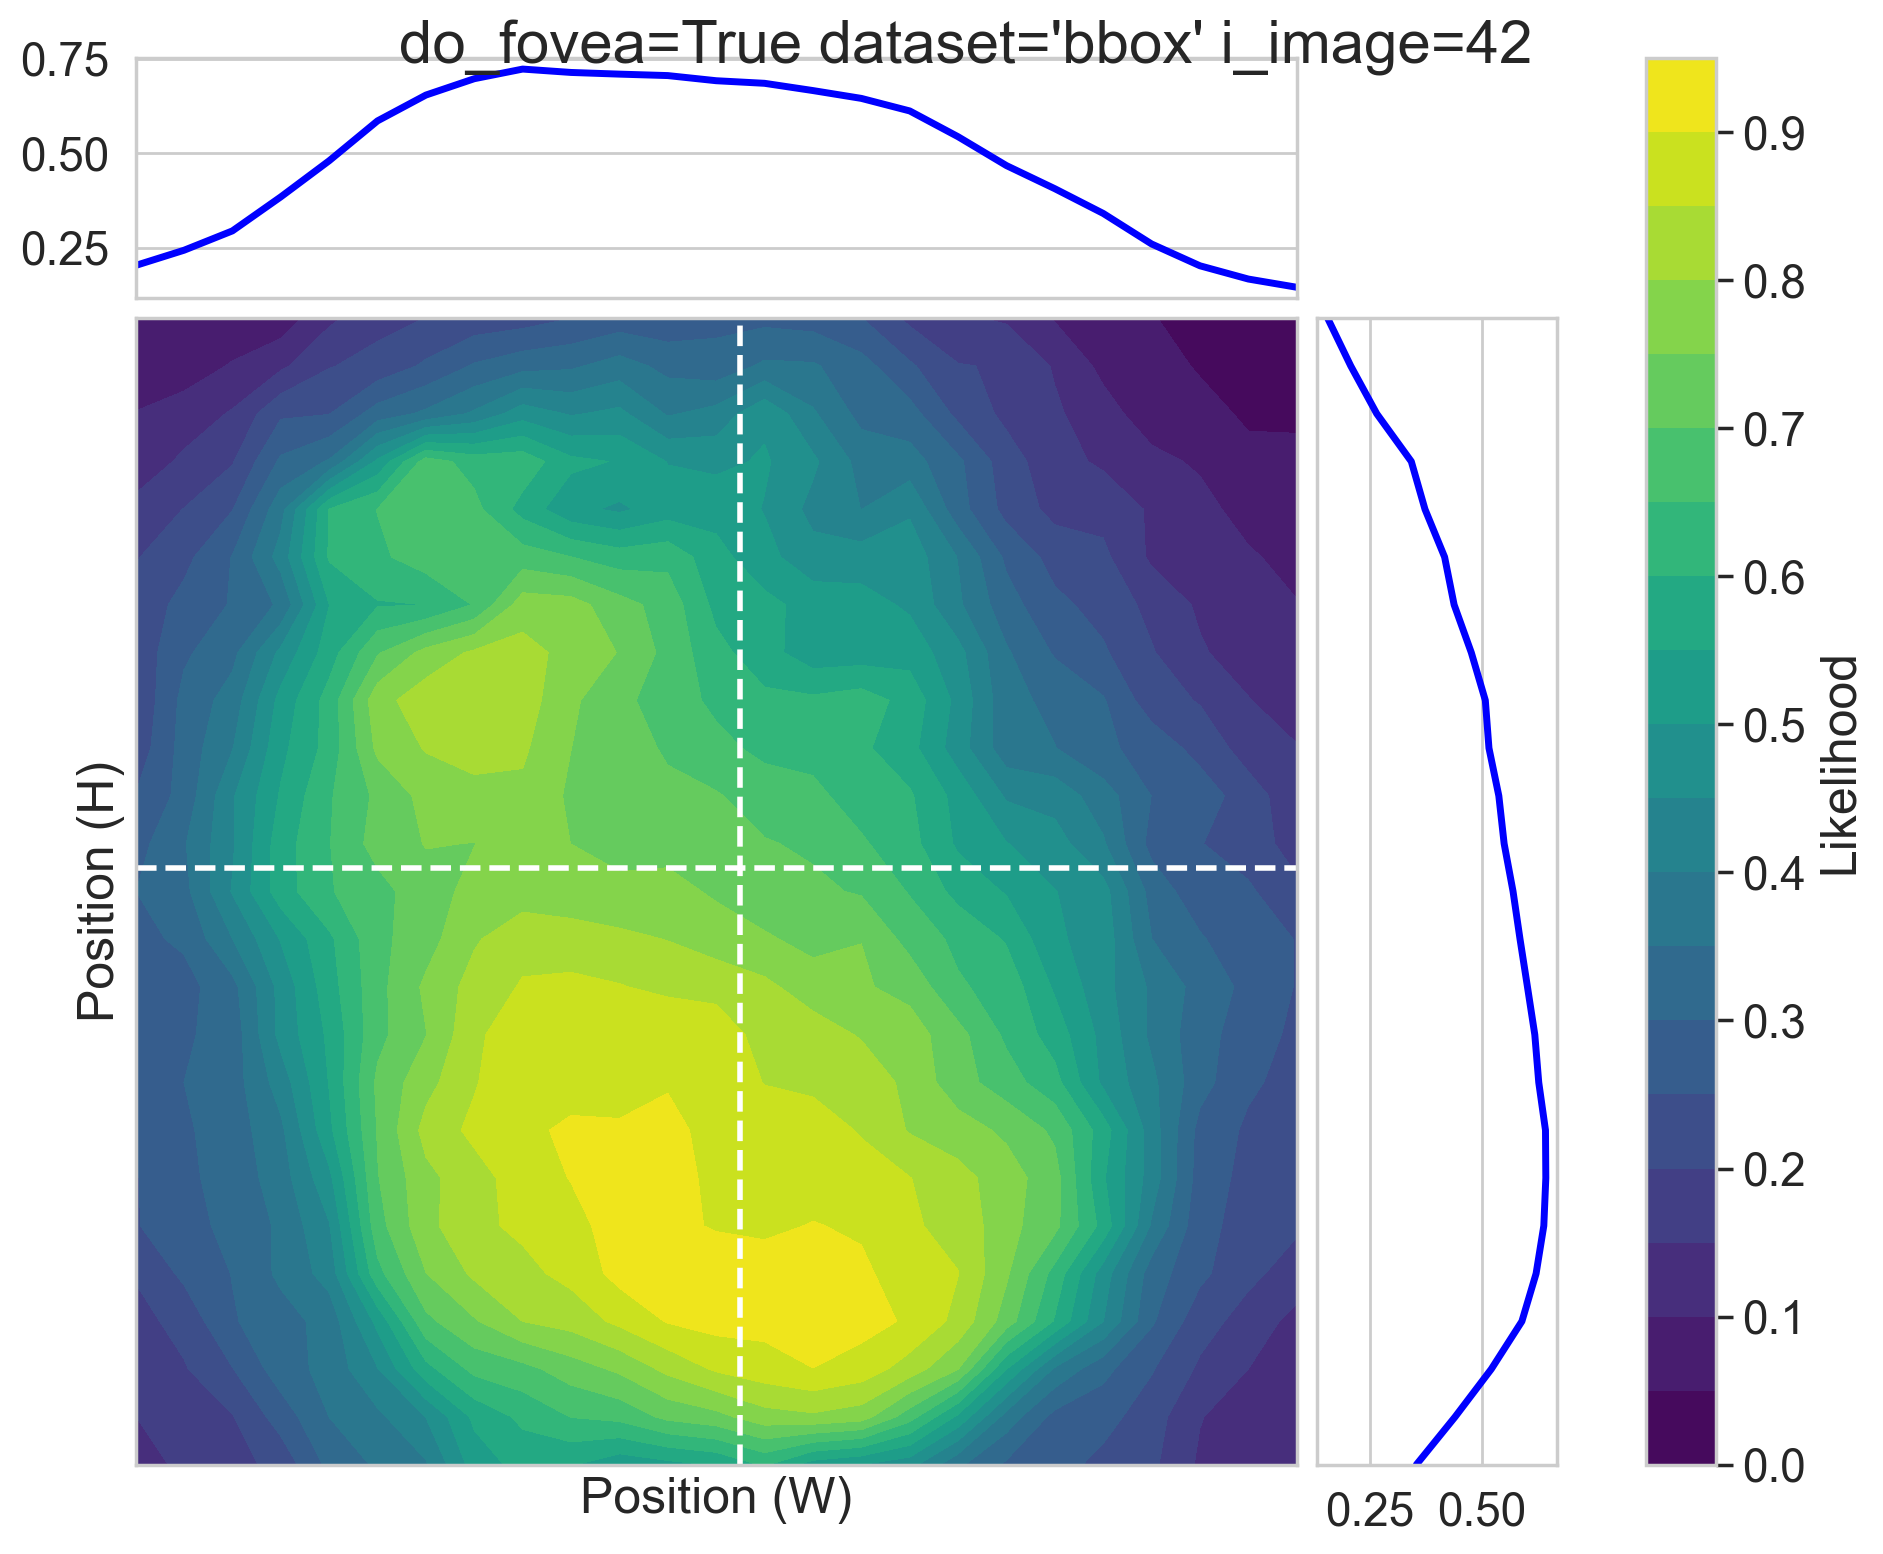

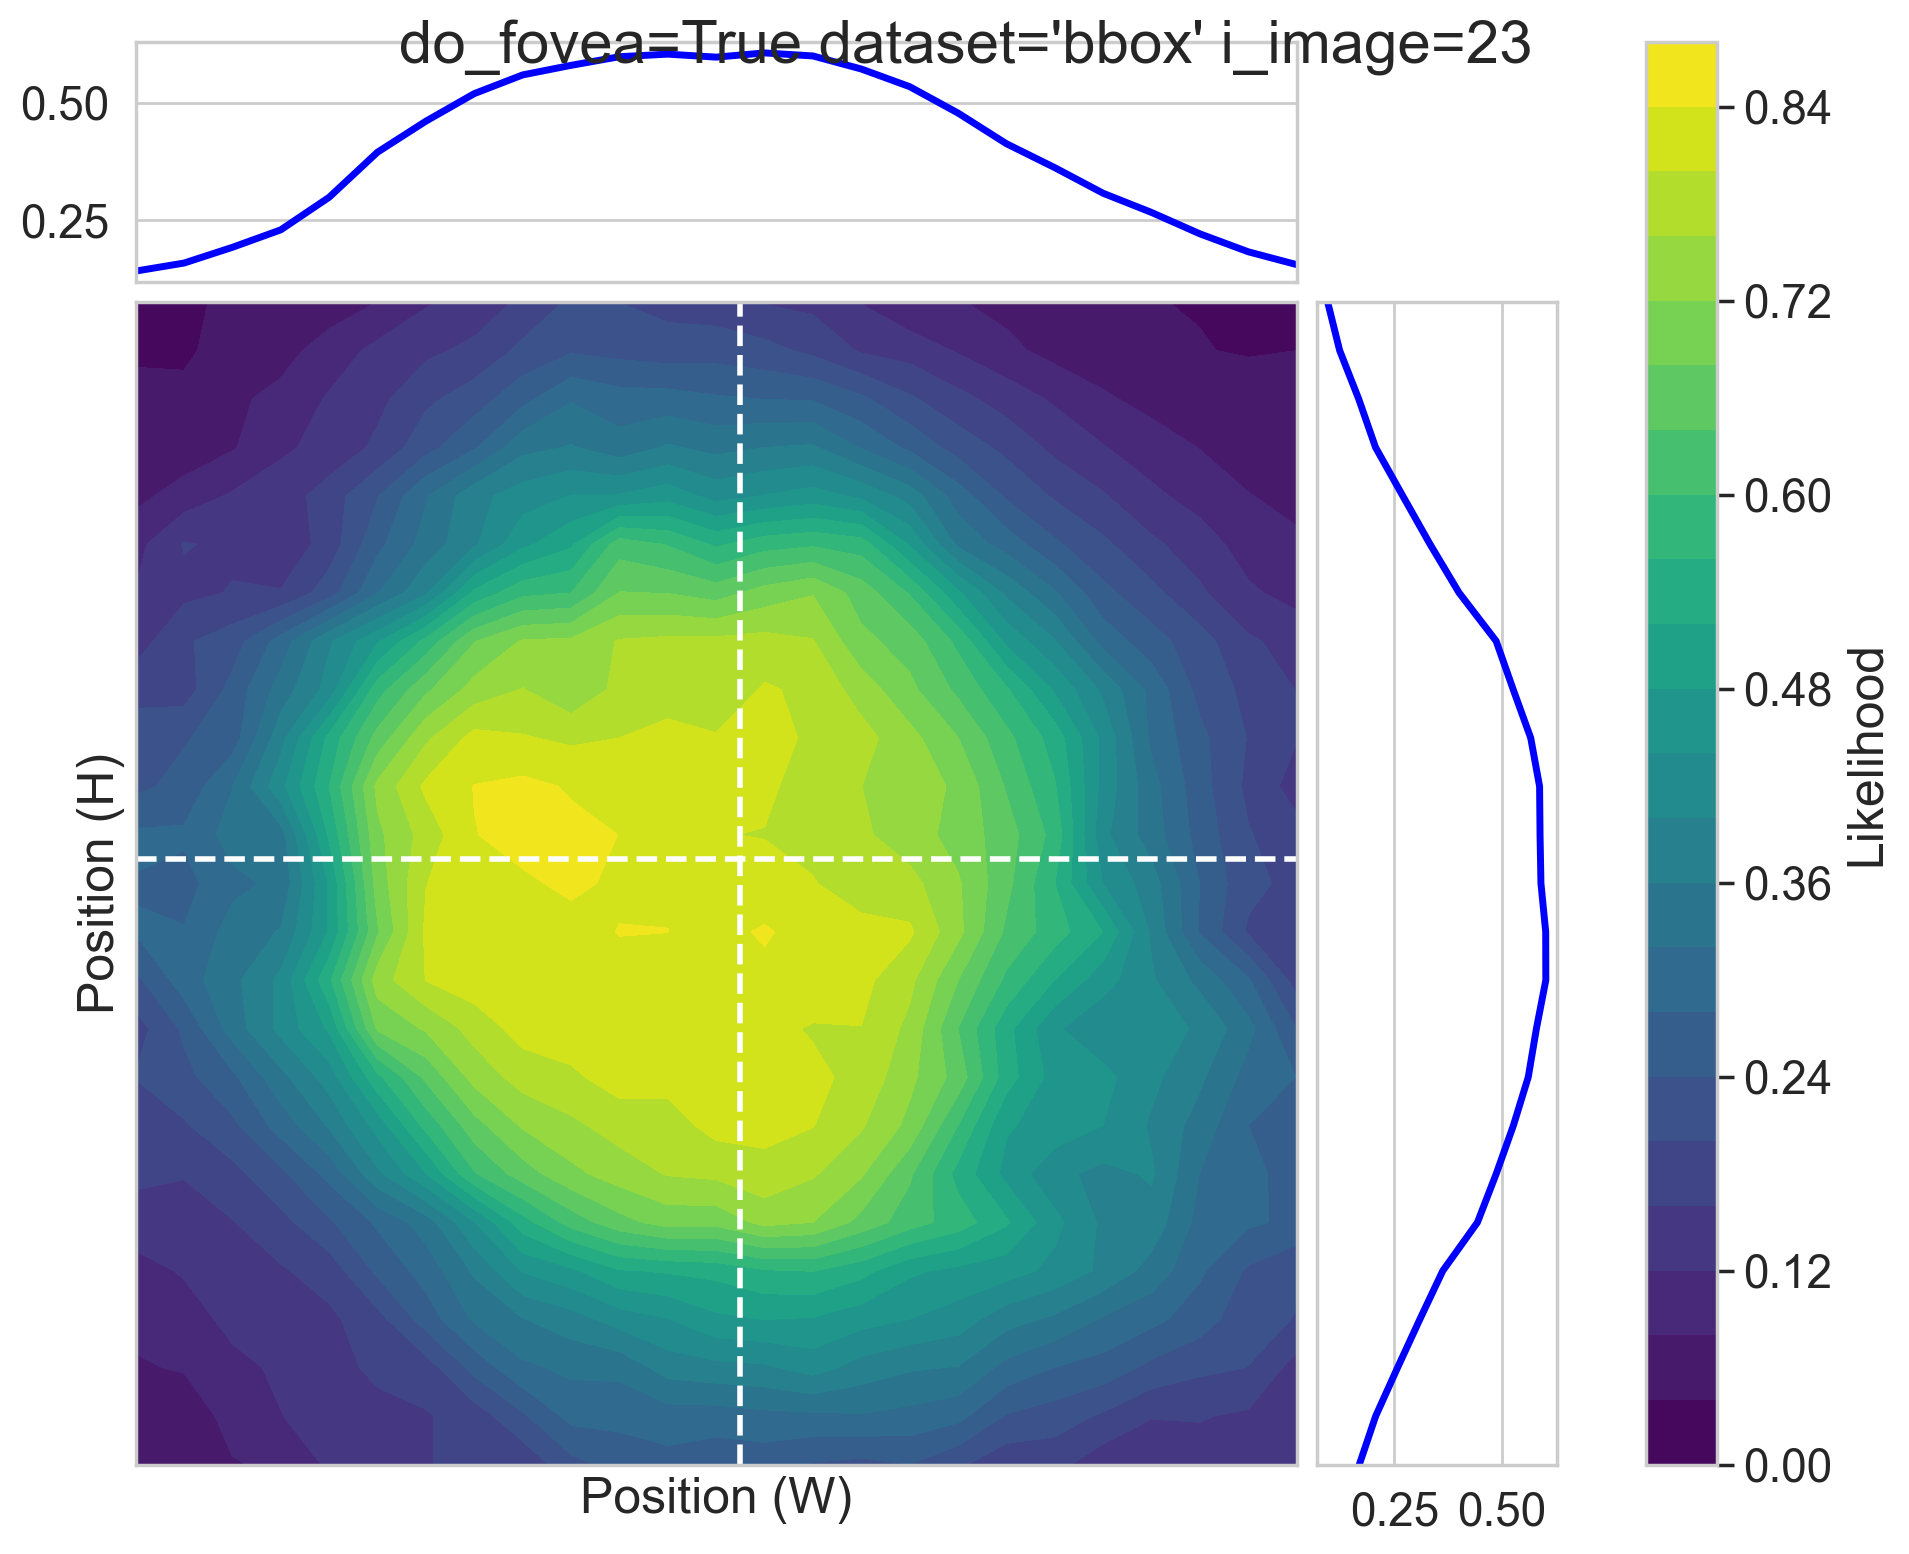

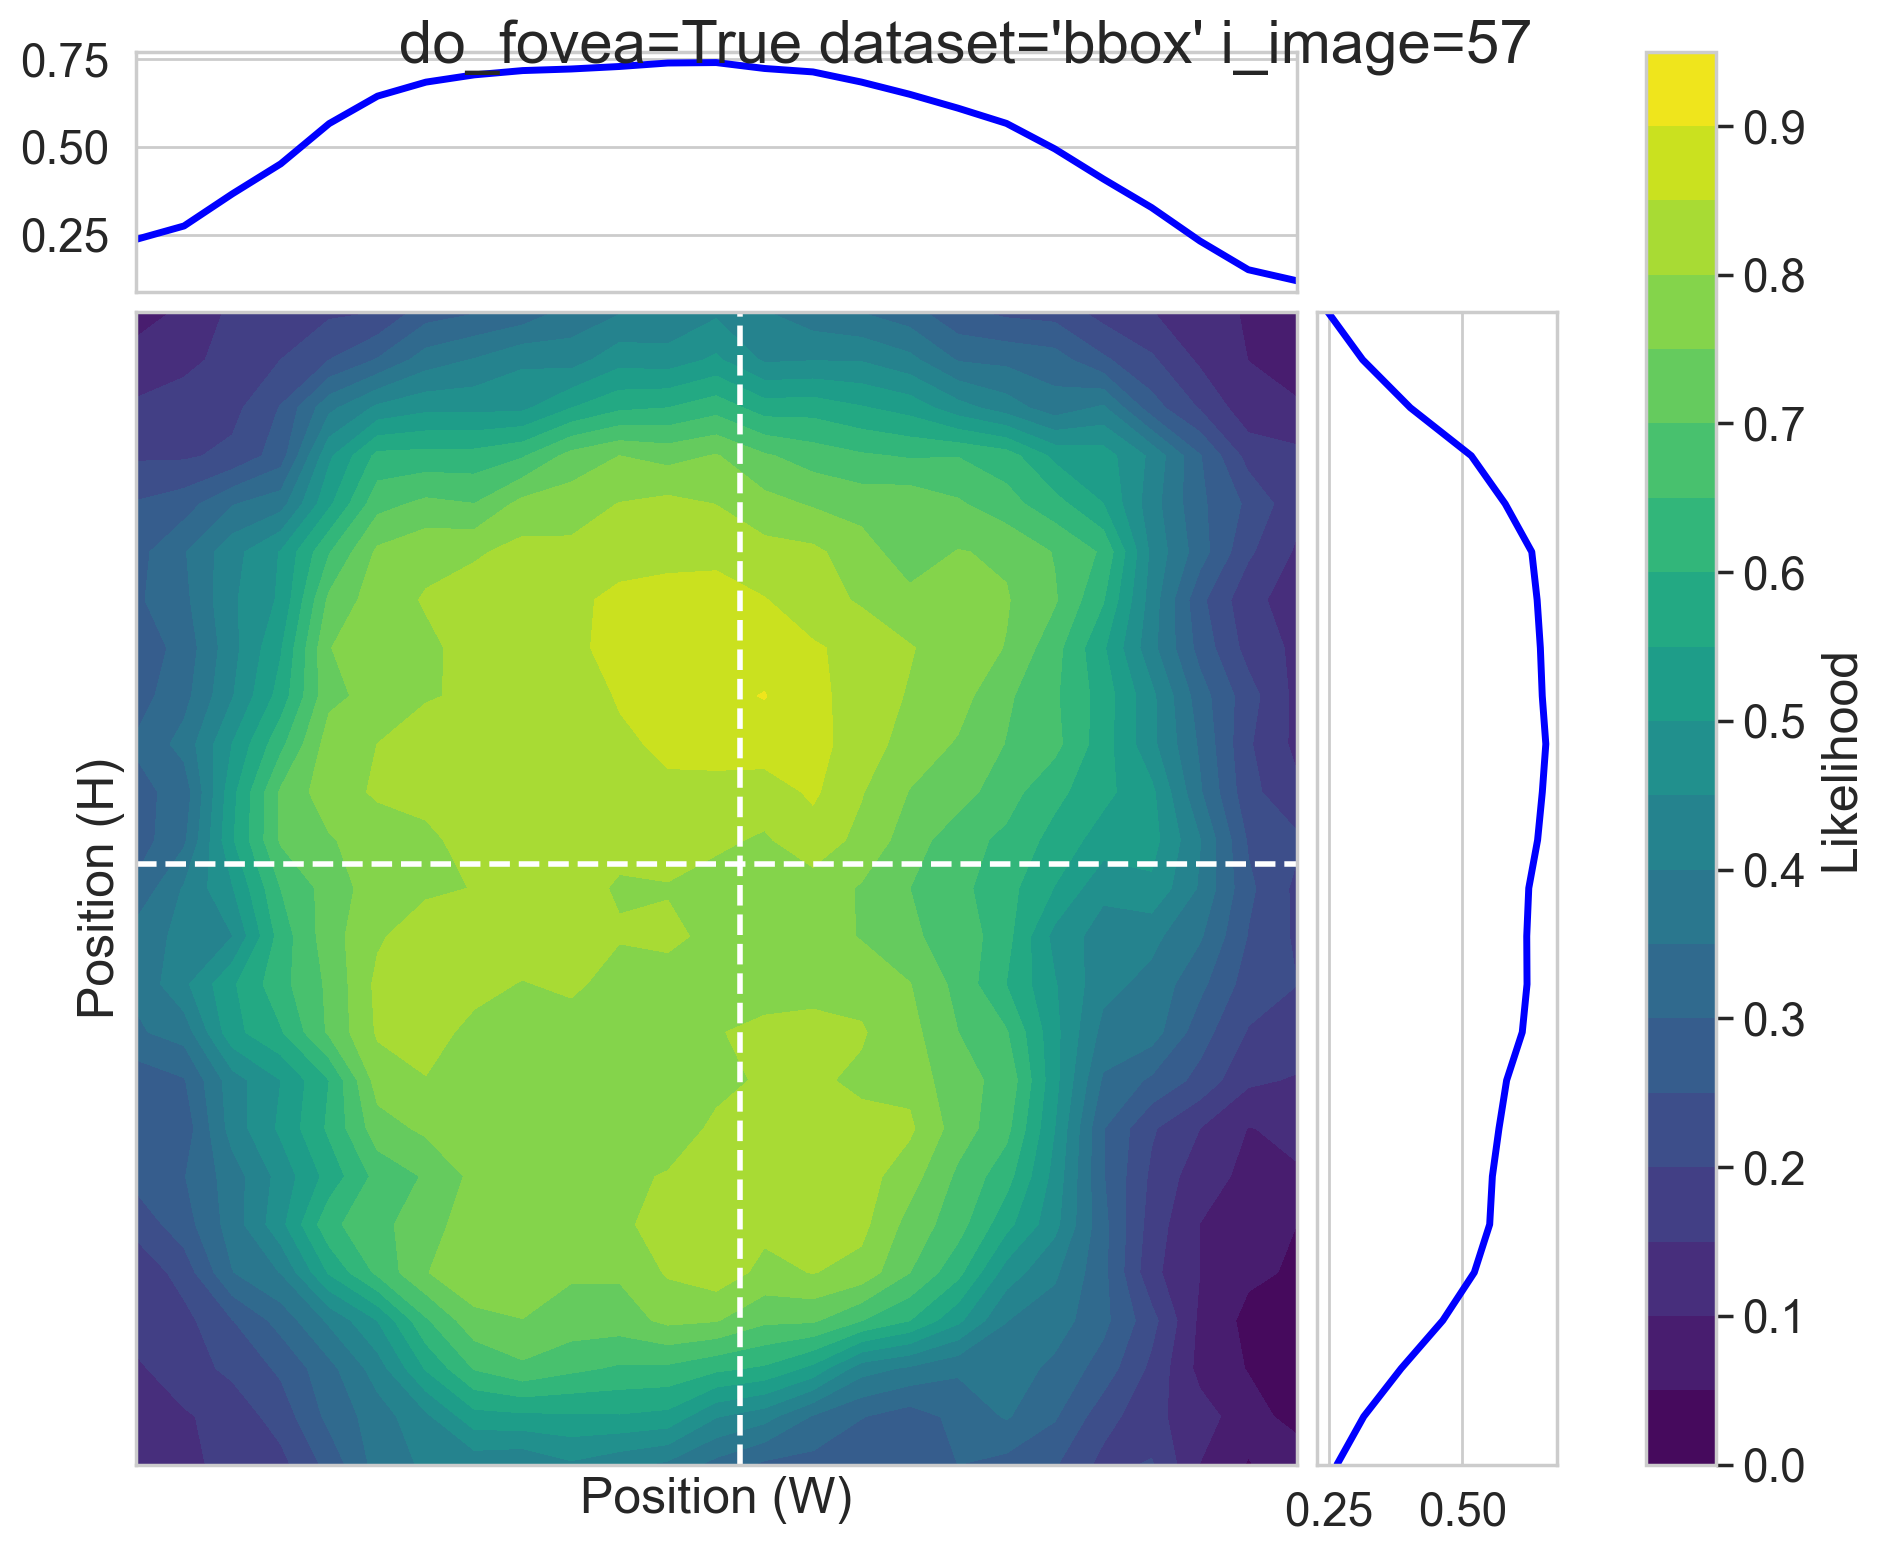

In [33]:
for do_fovea in do_foveas:
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']
            likelihood_maps_label_max = data['likelihood_maps_label_max']
            size_ratio_max = data['size_ratio_max']


        for i_image in [42, 23, 57]:
            fig, axes = fovea.visualize_likelihood_map(likelihood_maps_label[:, :, i_image], sigma=.5)
            fig.suptitle(f'{do_fovea=} {dataset=} {i_image=}')
            fovea.plt.show()

## fitting and doing stats


In [21]:
sigma = .5
gaussian_max_dfs = {}
gaussian_label_dfs = {}

for do_fovea in do_foveas:
    gaussian_label_dfs[do_fovea] = {}
    gaussian_max_dfs[do_fovea] = {}
    for dataset in all_datasets:

        npz_filename = args.data_cache / f'42_likelihood_maps_dataset={dataset}_{do_fovea=}.npz'
        with fovea.np.load(npz_filename) as data:
            likelihood_maps_label = data['likelihood_maps_label']
            likelihood_maps_max = data['likelihood_maps_max']


        gaussian_label_dfs[do_fovea][dataset] = fovea.compute_gaussian_params(likelihood_maps_label, sigma=sigma)
        gaussian_max_dfs[do_fovea][dataset] = fovea.compute_gaussian_params(likelihood_maps_max, sigma=sigma)

        # Example: Check if sigma_x is usually bigger than sigma_y
        is_sigma_x_bigger = gaussian_df["sigma_x"] > gaussian_df["sigma_y"]
        print(f"Fraction of images where sigma_x > sigma_y (more horizontal): {is_sigma_x_bigger.mean():.2f}")
        print(f"Fraction of images where sigma_y > sigma_x (more vertical): {(~is_sigma_x_bigger).mean():.2f}")

  0%|          | 0/397 [00:00<?, ?it/s]

,amplitude,x0,y0,sigma_x,sigma_y,theta,theta_deg,sigma_major,sigma_minor,elongation,sigma
0,0.071164,-1.000000,-0.684604,0.917487,0.326227,0.017268,0.989378,0.917487,0.326227,2.812421,0.547091
1,1.000000,-0.339180,-0.000627,0.704107,0.512894,0.657354,37.663600,0.704107,0.512894,1.372814,0.600943
2,0.993944,-0.096395,-0.097699,0.605738,0.984255,-0.033865,-1.940318,0.984255,0.605738,1.624887,0.772140
3,0.507927,-0.150918,-0.027842,0.759684,0.675990,-0.646664,-37.051104,0.759684,0.675990,1.123809,0.716616
4,0.200686,-0.017008,0.189100,0.506198,0.233110,0.565655,32.409653,0.506198,0.233110,2.171501,0.343511


In [22]:
# Example: Check if sigma_x is usually bigger than sigma_y
is_sigma_x_bigger = gaussian_df["sigma_x"] > gaussian_df["sigma_y"]
print(f"Fraction of images where sigma_x > sigma_y (more horizontal): {is_sigma_x_bigger.mean():.2f}")
print(f"Fraction of images where sigma_y > sigma_x (more vertical): {(~is_sigma_x_bigger).mean():.2f}")

Fraction of images where sigma_x > sigma_y (more horizontal): 0.37
Fraction of images where sigma_y > sigma_x (more vertical): 0.63


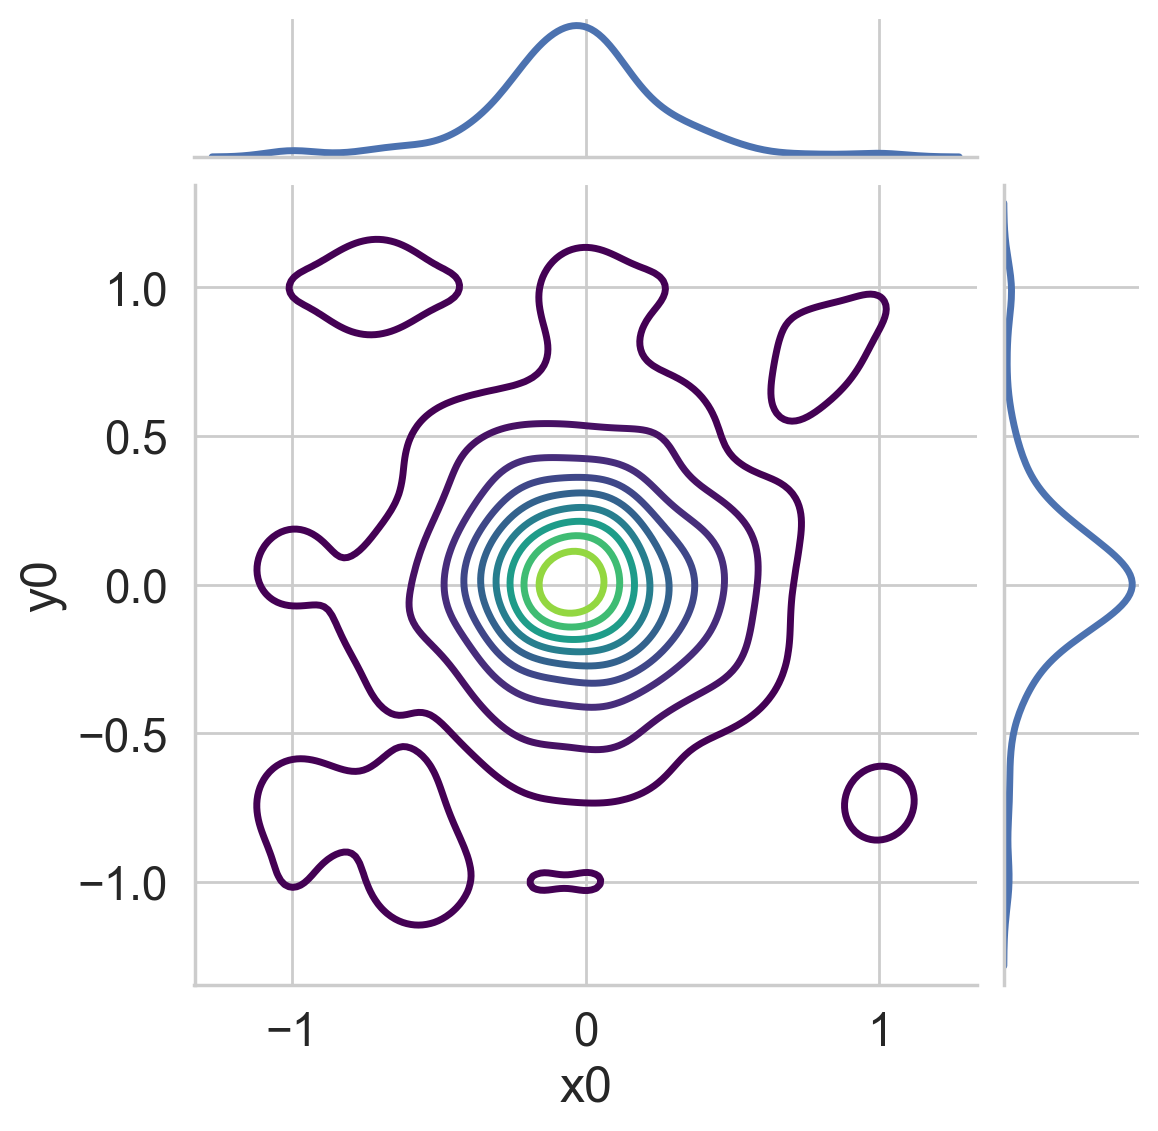

In [ ]:
for do_fovea, c_fovea in zip([True, False], ['viridis', 'plasma']):
    for dataset in fovea.params.all_datasets:     
        g = fovea.sns.jointplot(
            data=gaussian_label_dfs[do_fovea][dataset],
            x="x0",
            y="y0",
            # kind="kde",
            cmap=c_fovea,
        )
        g.fig.suptitle(f"{'foveated' if do_fovea else 'uniform'} - dataset={dataset}")
fovea.plt.show()

/Users/laurentperrinet/sdrive_cnrs/hot_from_git/Retinotopy_project/retinoto_py/.venv/lib/python3.14/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


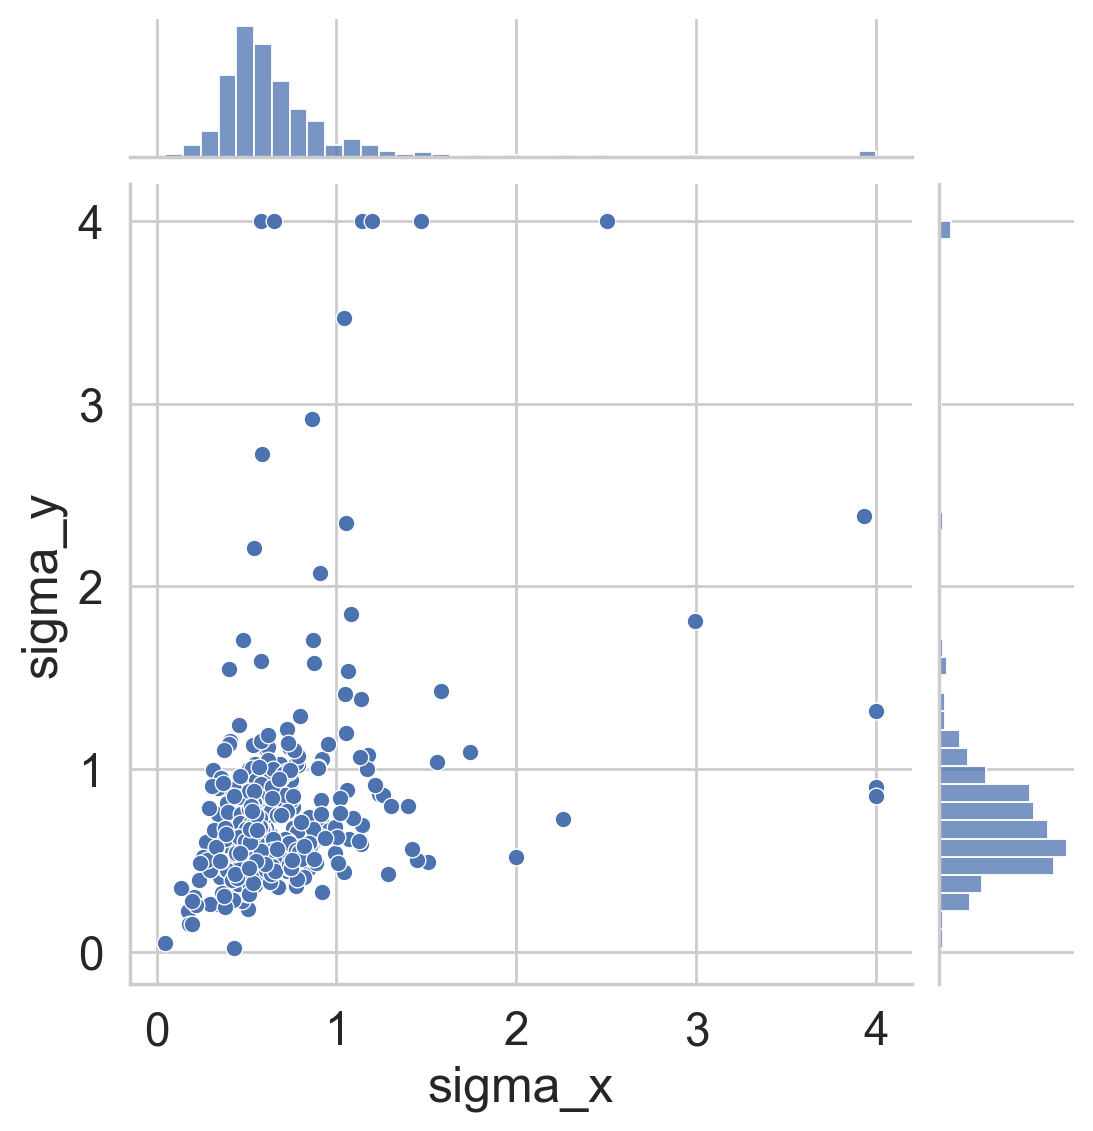

In [24]:
# Joint KDE plot with marginals
g = fovea.sns.jointplot(
    data=gaussian_df,
    x="sigma_x",
    y="sigma_y",
    kind="scatter",
    cmap="viridis",
)
# plt.show()

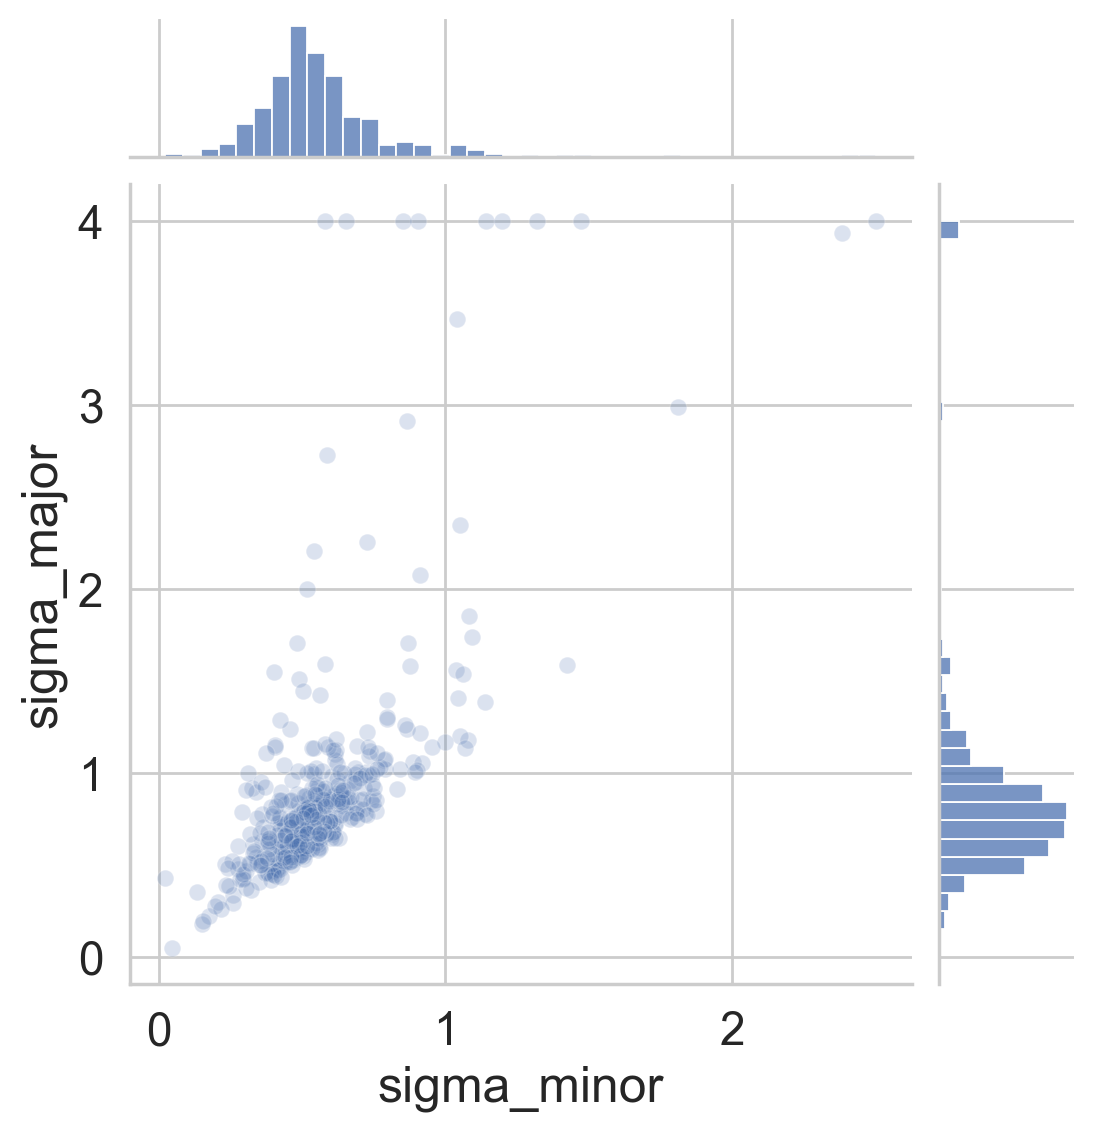

In [25]:
# Joint KDE plot with marginals
g = fovea.sns.jointplot(
    data=gaussian_df,
    x="sigma_minor",
    y="sigma_major",
    kind="scatter",
    alpha=.2,
)
# plt.show()

Text(1.3, 108, ' Peak @ 0.57')

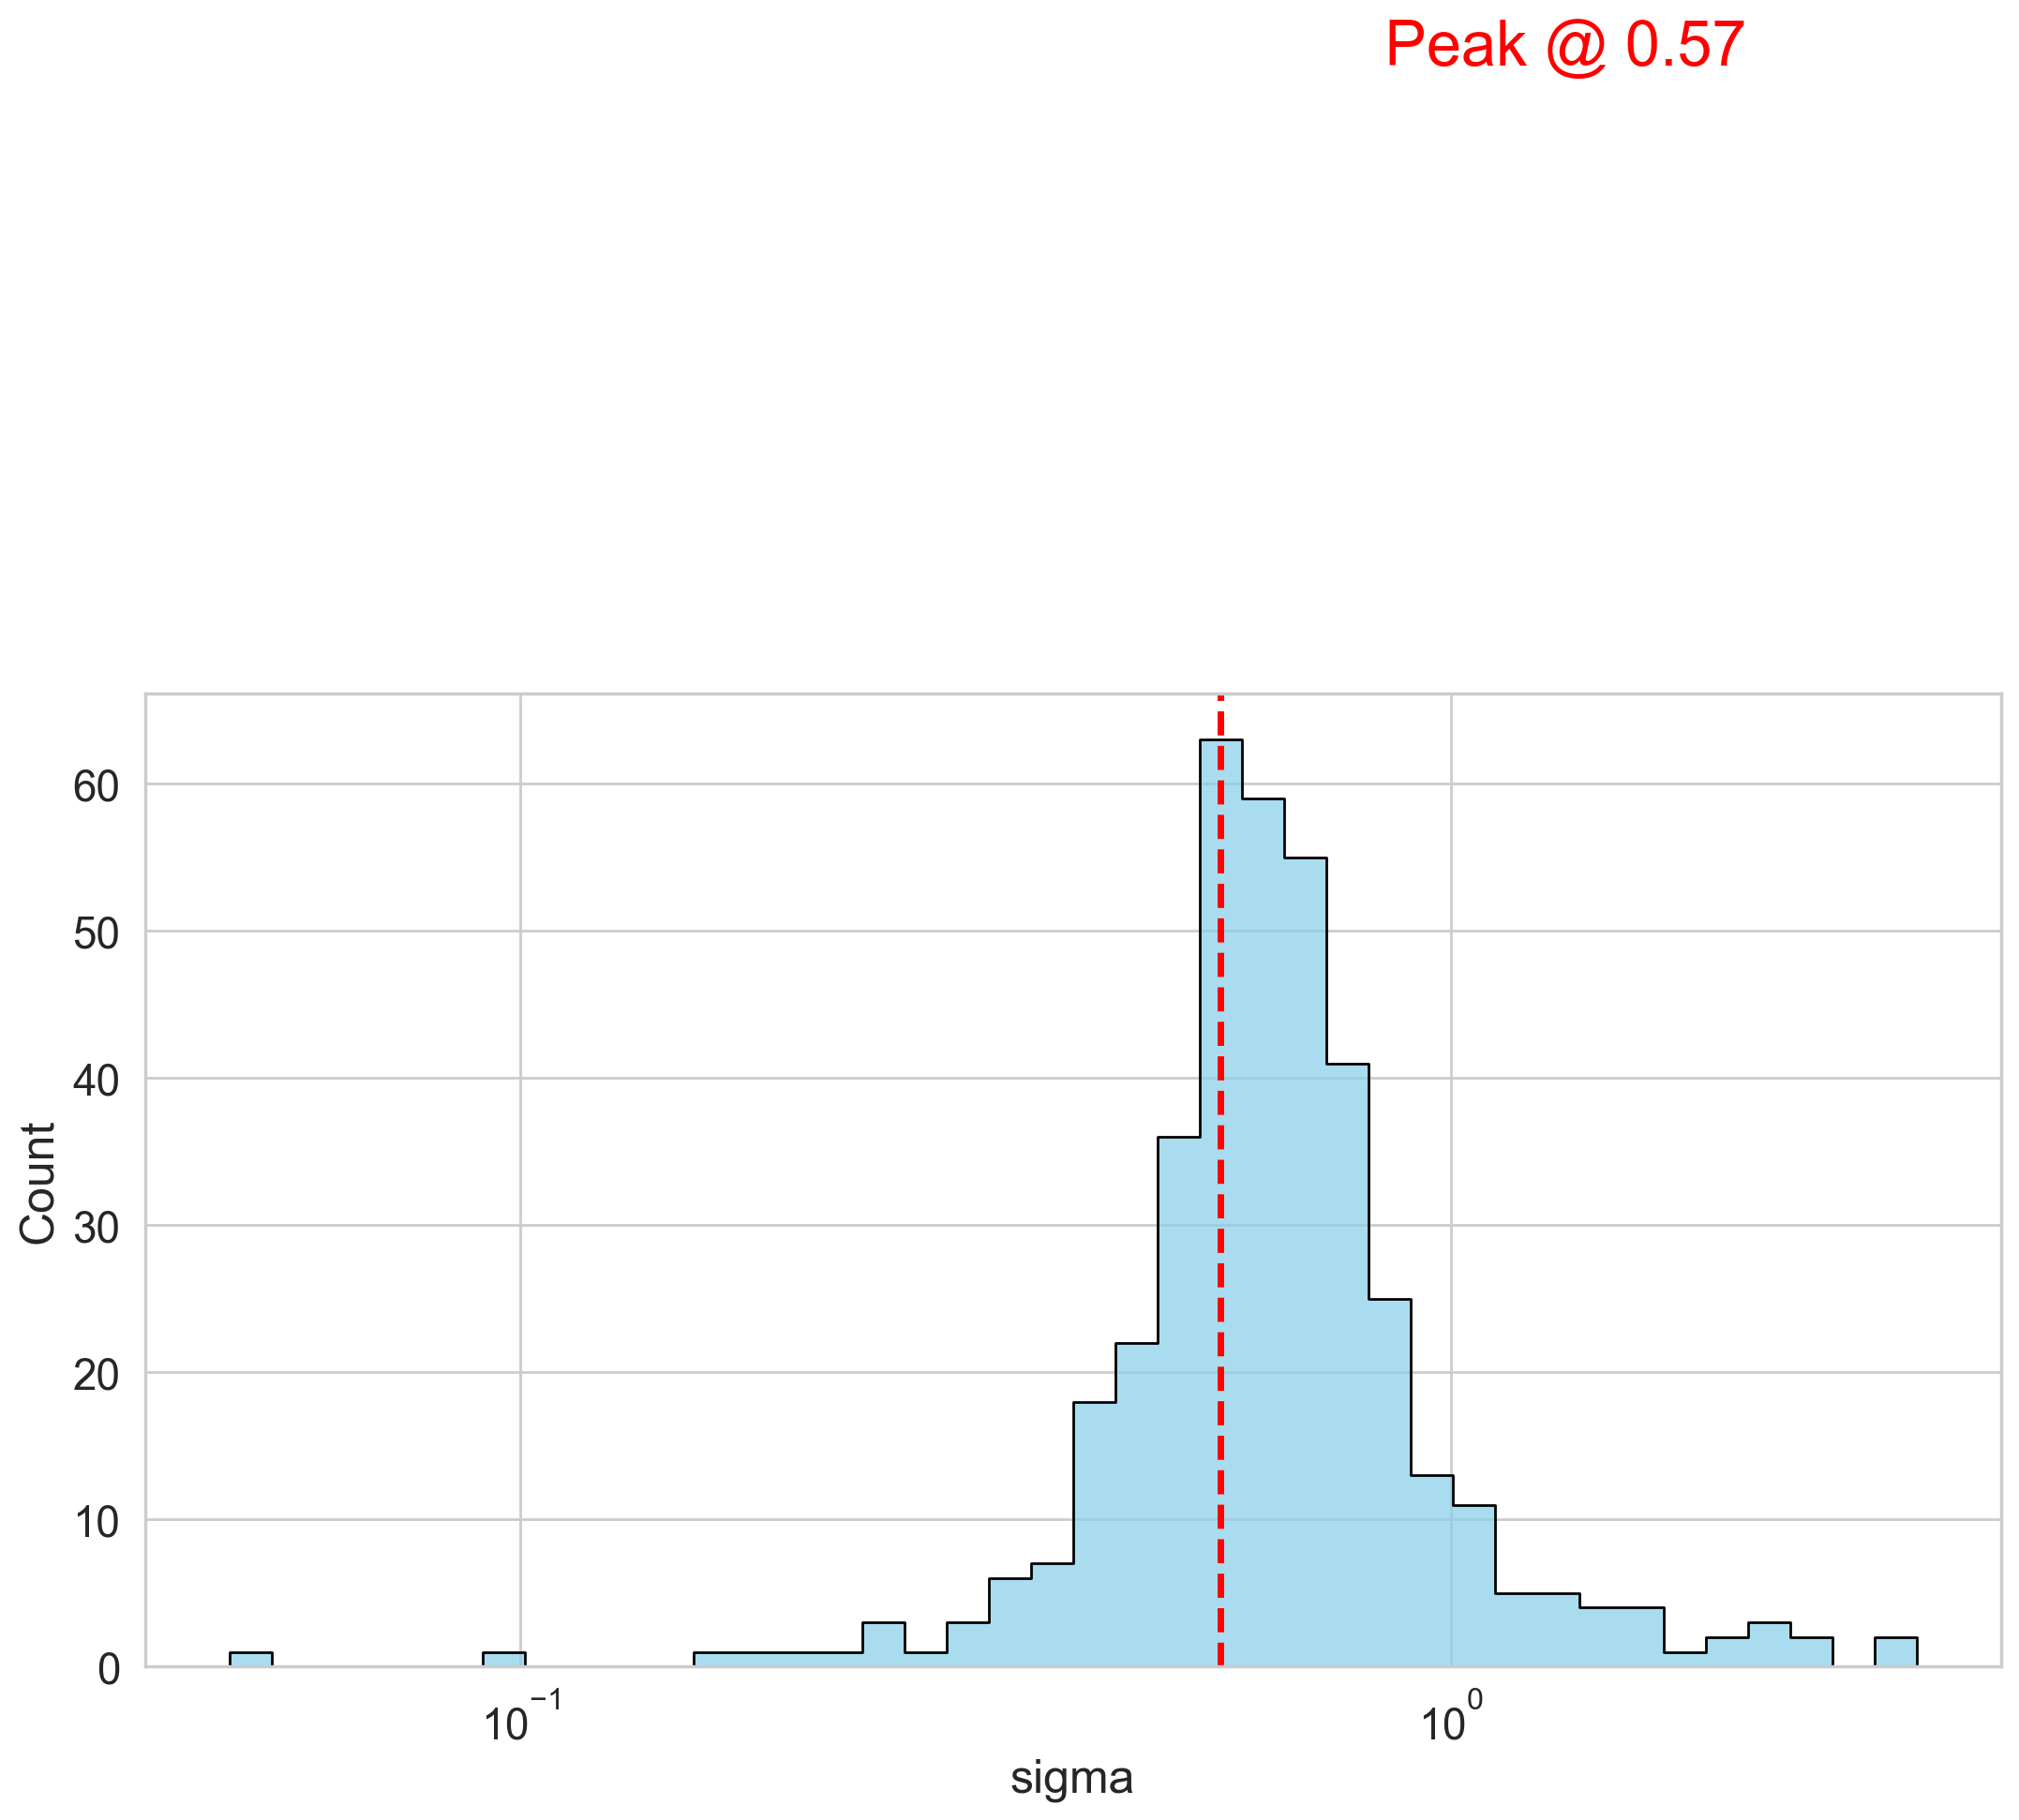

In [26]:
import numpy as np

for dataset in ['bbox']: #fovea.params.all_datasets:
    fig, ax = fovea.plt.subplots()

    for do_fovea, c_fovea in zip([True, False], ['skyblue', 'green']):
        print(dataset, do_fovea)       
        gaussian_df = gaussian_max_dfs[do_fovea][dataset]
        g = fovea.sns.histplot(
            ax=ax,
            data=gaussian_df,
            x='sigma',
            bins=40,
            element='step',  # Use step plots for clarity
            kde=False,  # Disable KDE for log-scaled x-axis
            color=c_fovea,
            alpha=0.7,
            edgecolor='black',
            log_scale=(True, False),  # Log scale only for the x-axis
            label=f'{'foveated' if do_fovea else 'uniform'}'
        )

        # Compute the peak (bin with the highest count)
        counts, bin_edges = np.histogram(np.log(gaussian_df['sigma']), bins=40)
        peak_bin_index = np.argmax(counts)
        log_peak_value = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2  # Midpoint of the peak bin
        peak_count = counts[peak_bin_index]
        peak_value = np.exp(log_peak_value)

        # Annotate the peak on the plot
        fovea.plt.axvline(x=peak_value, color=c_fovea, linestyle='--')#, label=f'Peak: {peak_value:.2f}')
        fovea.plt.text(
            1.3,
            108 if do_fovea else 85,
            f' Peak @ {peak_value:.2f}',
            ha='center',
            va='bottom',
            color=c_fovea,
            fontsize=24,
            bbox=dict(facecolor='white', alpha=0., edgecolor='none'), 
        )
    ax.legend()
    fovea.plt.show()

Text(4, 80, ' Peak @ 1.41')

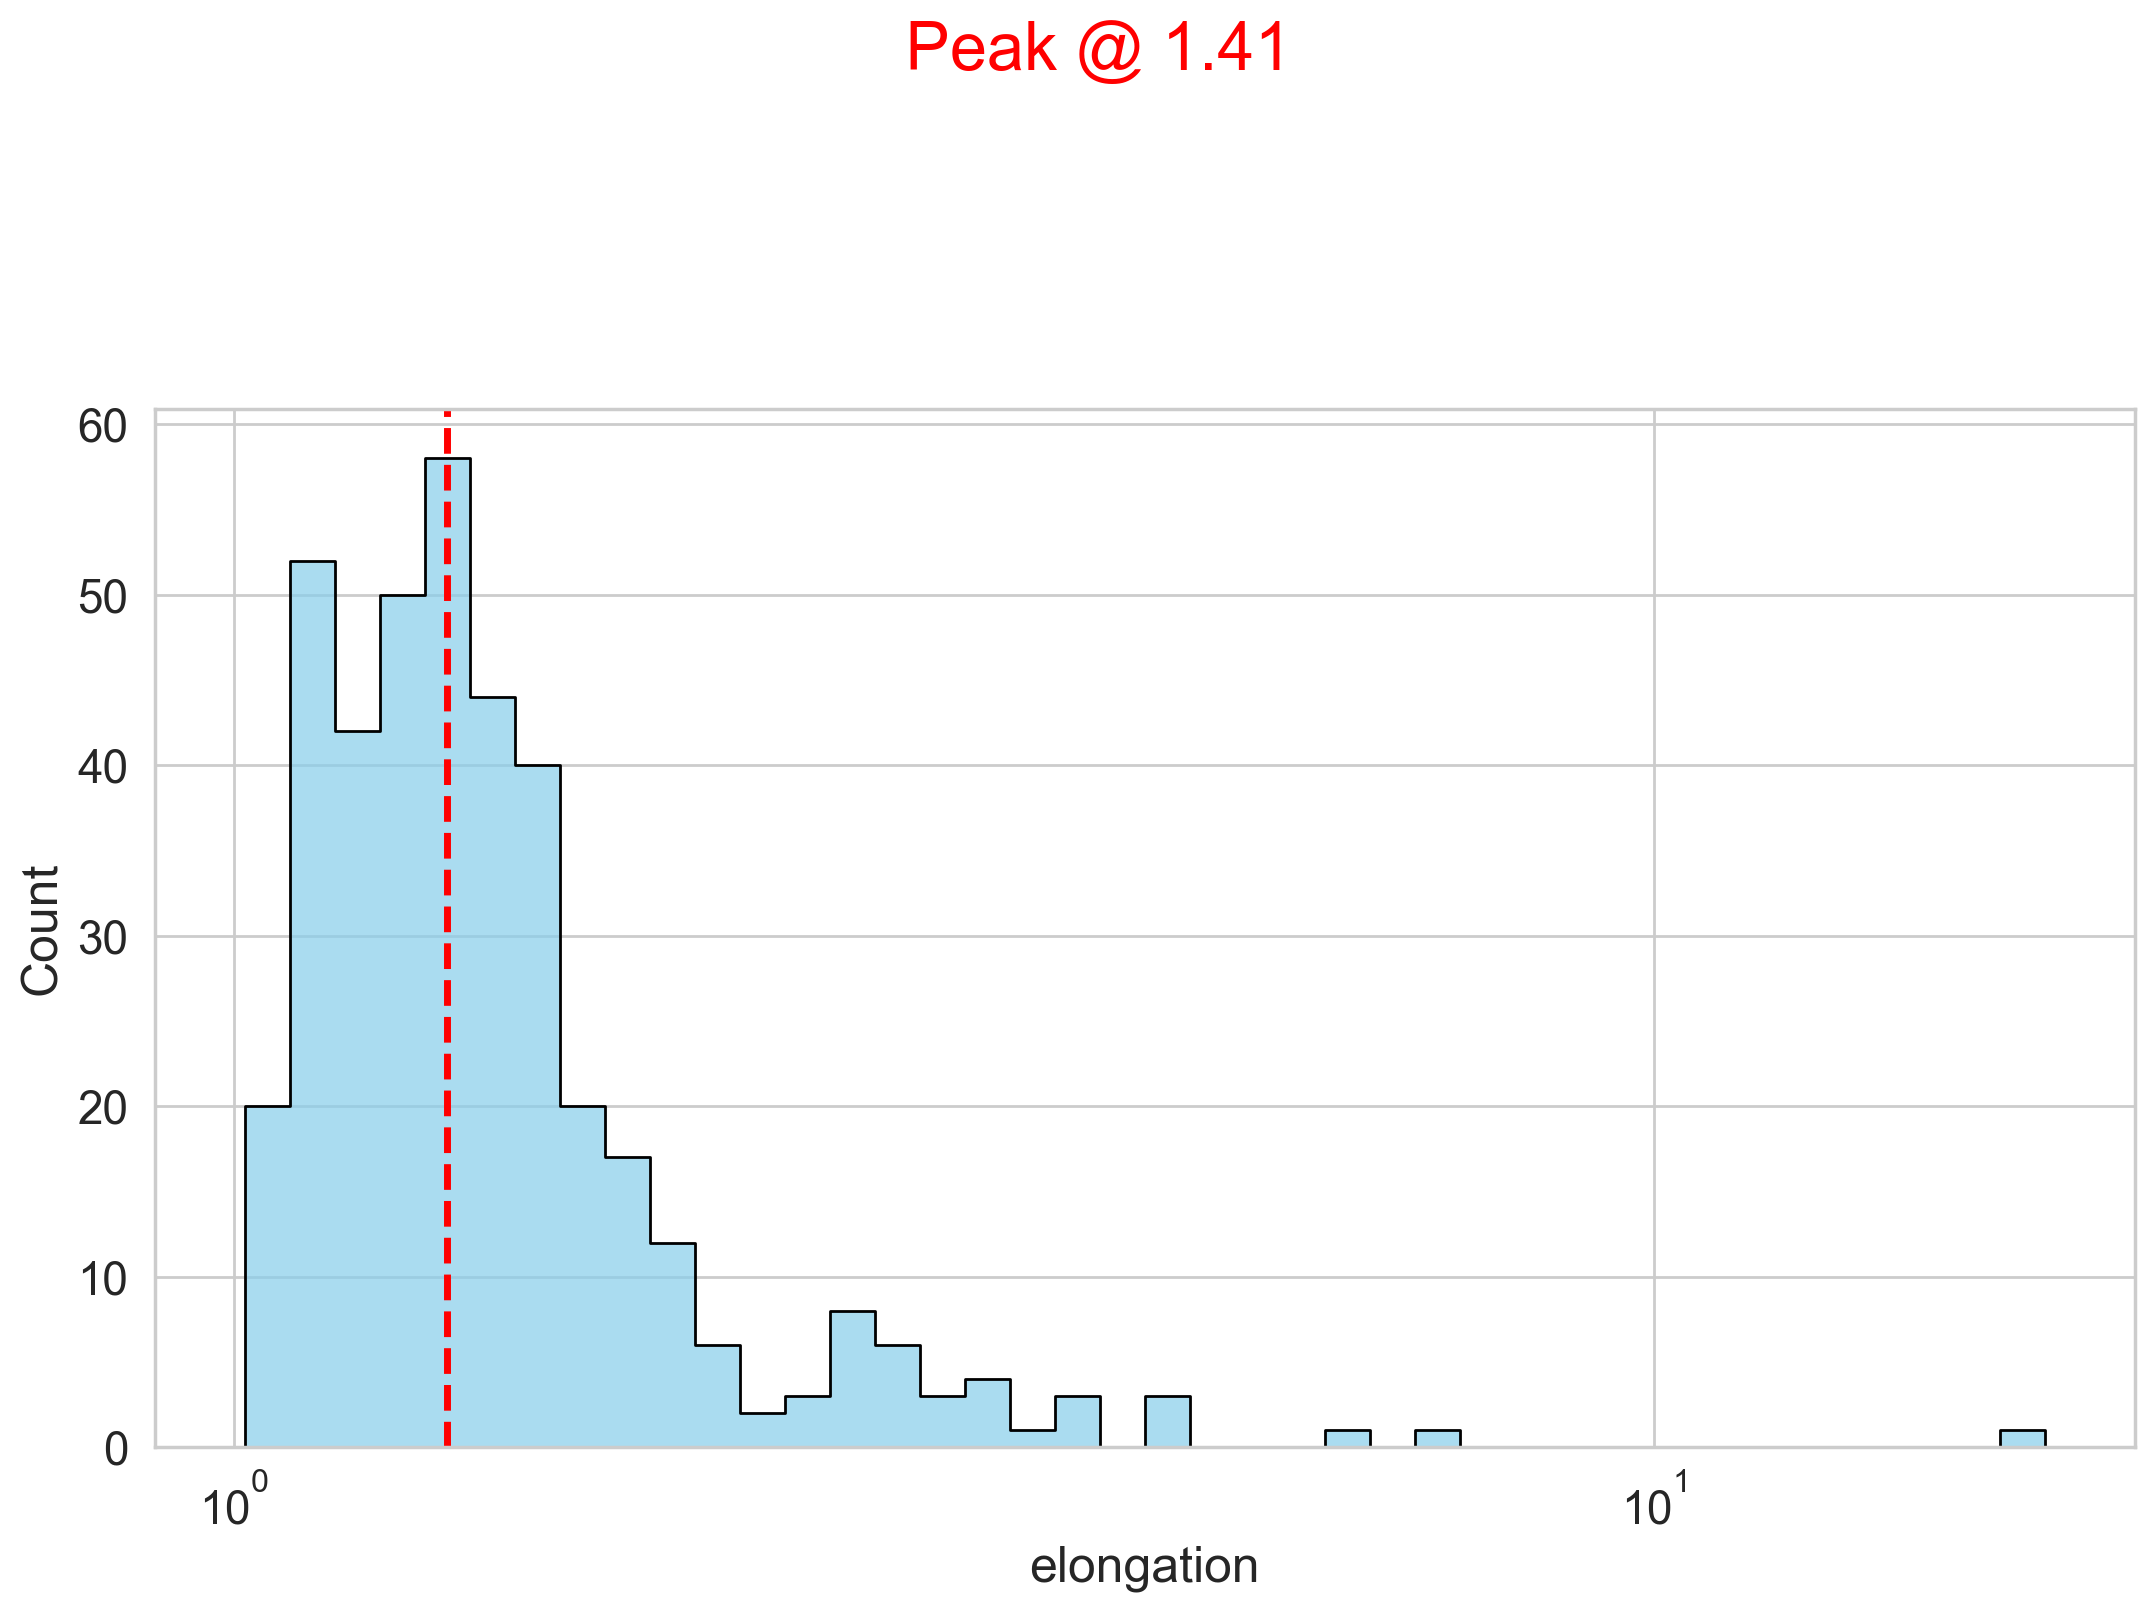

In [27]:
g = fovea.sns.histplot(
    data=gaussian_df,
    x='elongation',
    bins=40,
    element='step',  # Use step plots for clarity
    kde=False,  # Disable KDE for log-scaled x-axis
    color='skyblue',
    alpha=0.7,
    edgecolor='black',
    log_scale=(True, False)  # Log scale only for the x-axis
)

# Compute the peak (bin with the highest count)
counts, bin_edges = np.histogram(np.log(gaussian_df['elongation']), bins=40)
peak_bin_index = np.argmax(counts)
log_peak_value = (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1]) / 2  # Midpoint of the peak bin
peak_count = counts[peak_bin_index]
peak_value = np.exp(log_peak_value)

# Annotate the peak on the plot
fovea.plt.axvline(x=peak_value, color='red', linestyle='--', label=f'Peak: {peak_value:.2f}')
fovea.plt.text(
    4,
    80,
    f' Peak @ {peak_value:.2f}',
    ha='center',
    va='bottom',
    color='red',
    fontsize=24,
    bbox=dict(facecolor='white', alpha=0., edgecolor='none')
)

In [28]:
gaussian_df['elongation'].min(), gaussian_df['elongation'].max()

(np.float64(1.0166872964291602), np.float64(18.84003541938467))

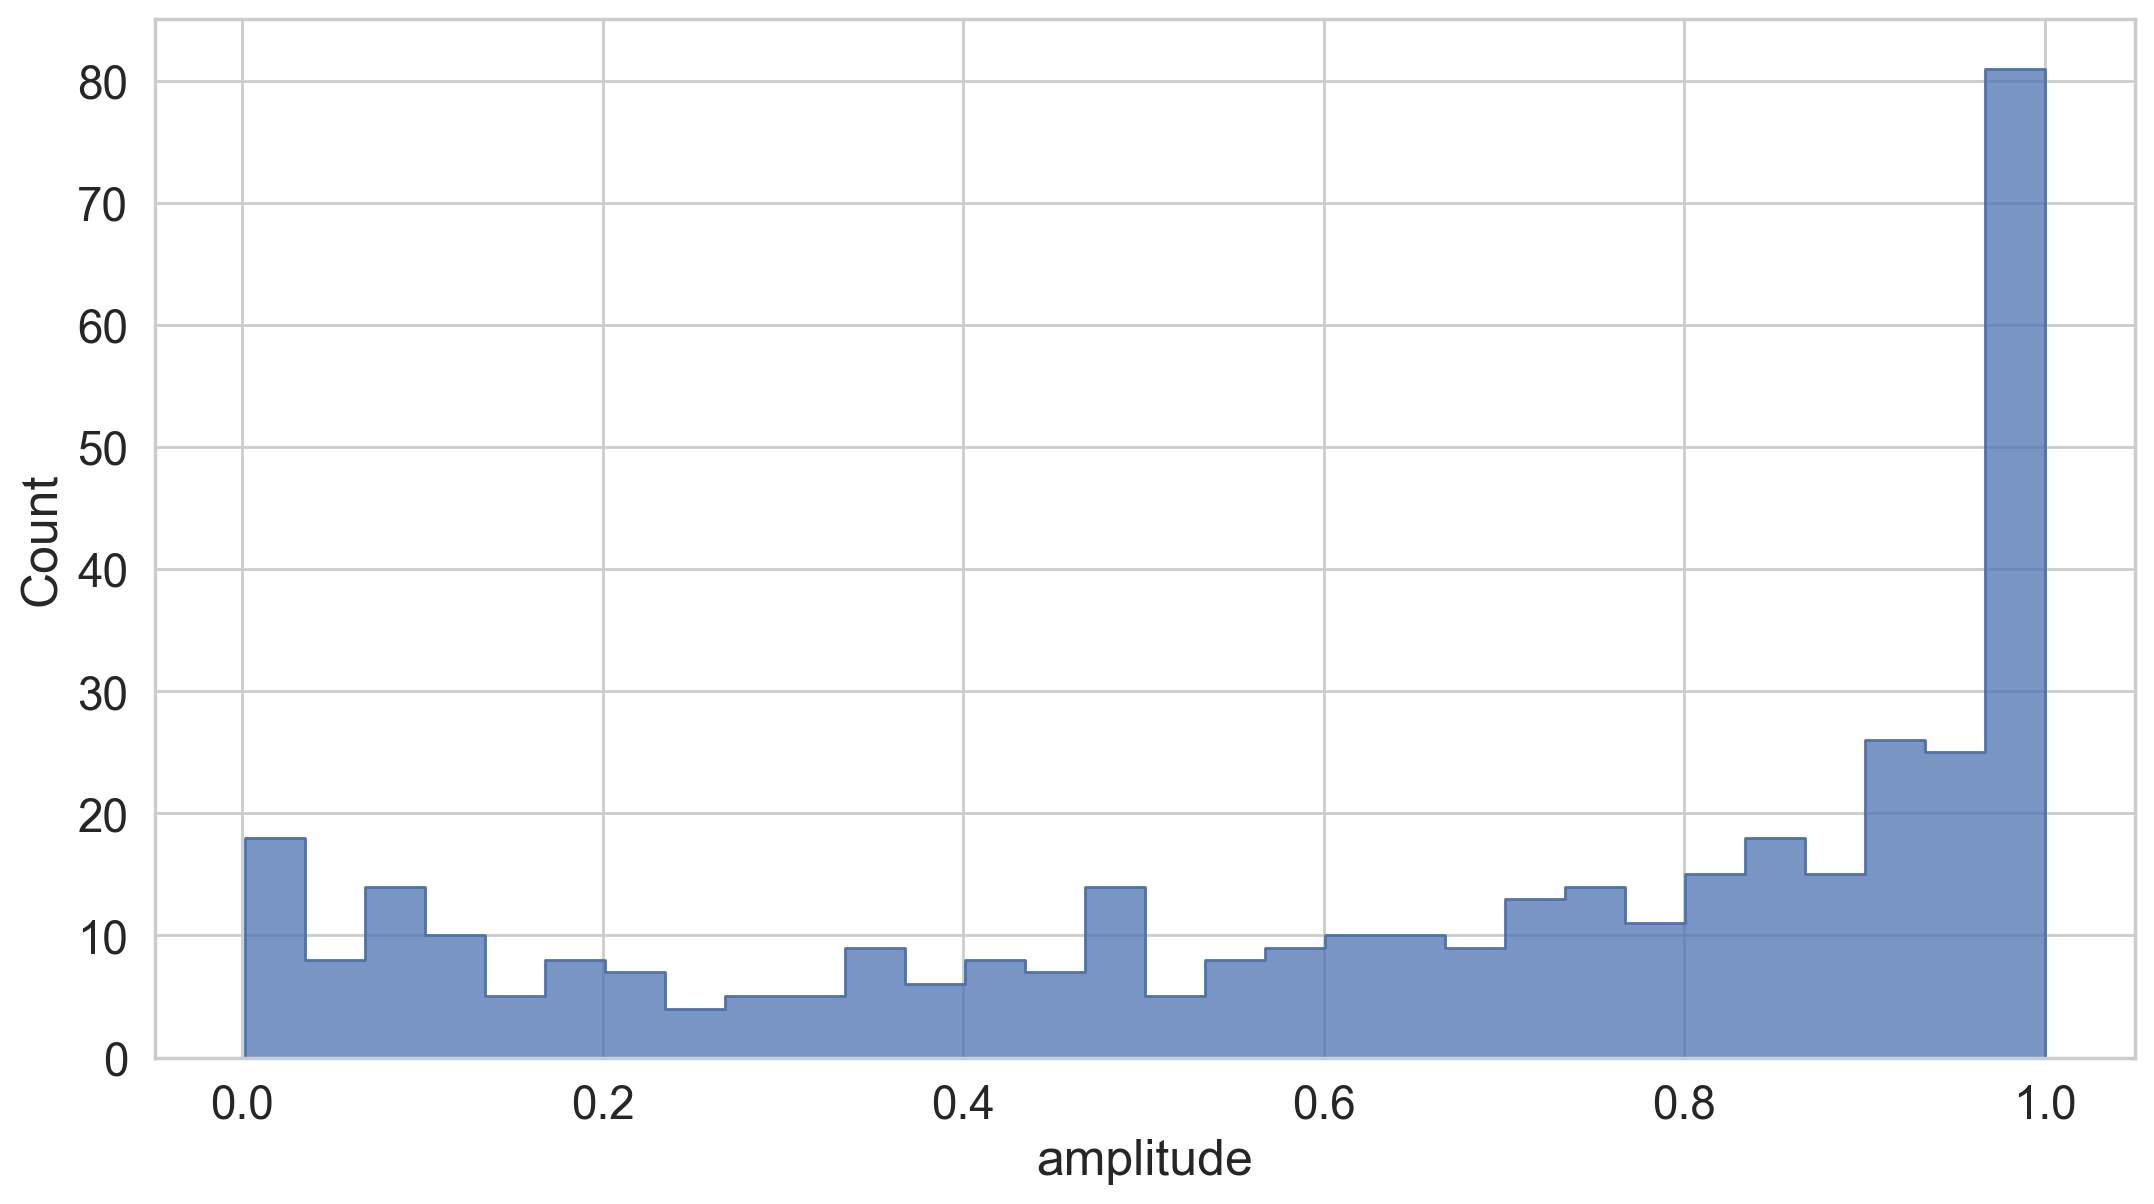

In [29]:
g = fovea.sns.histplot(
    data=gaussian_df,
    x='amplitude',
    bins=30,
    element='step'  # Use step plots for clarity
)


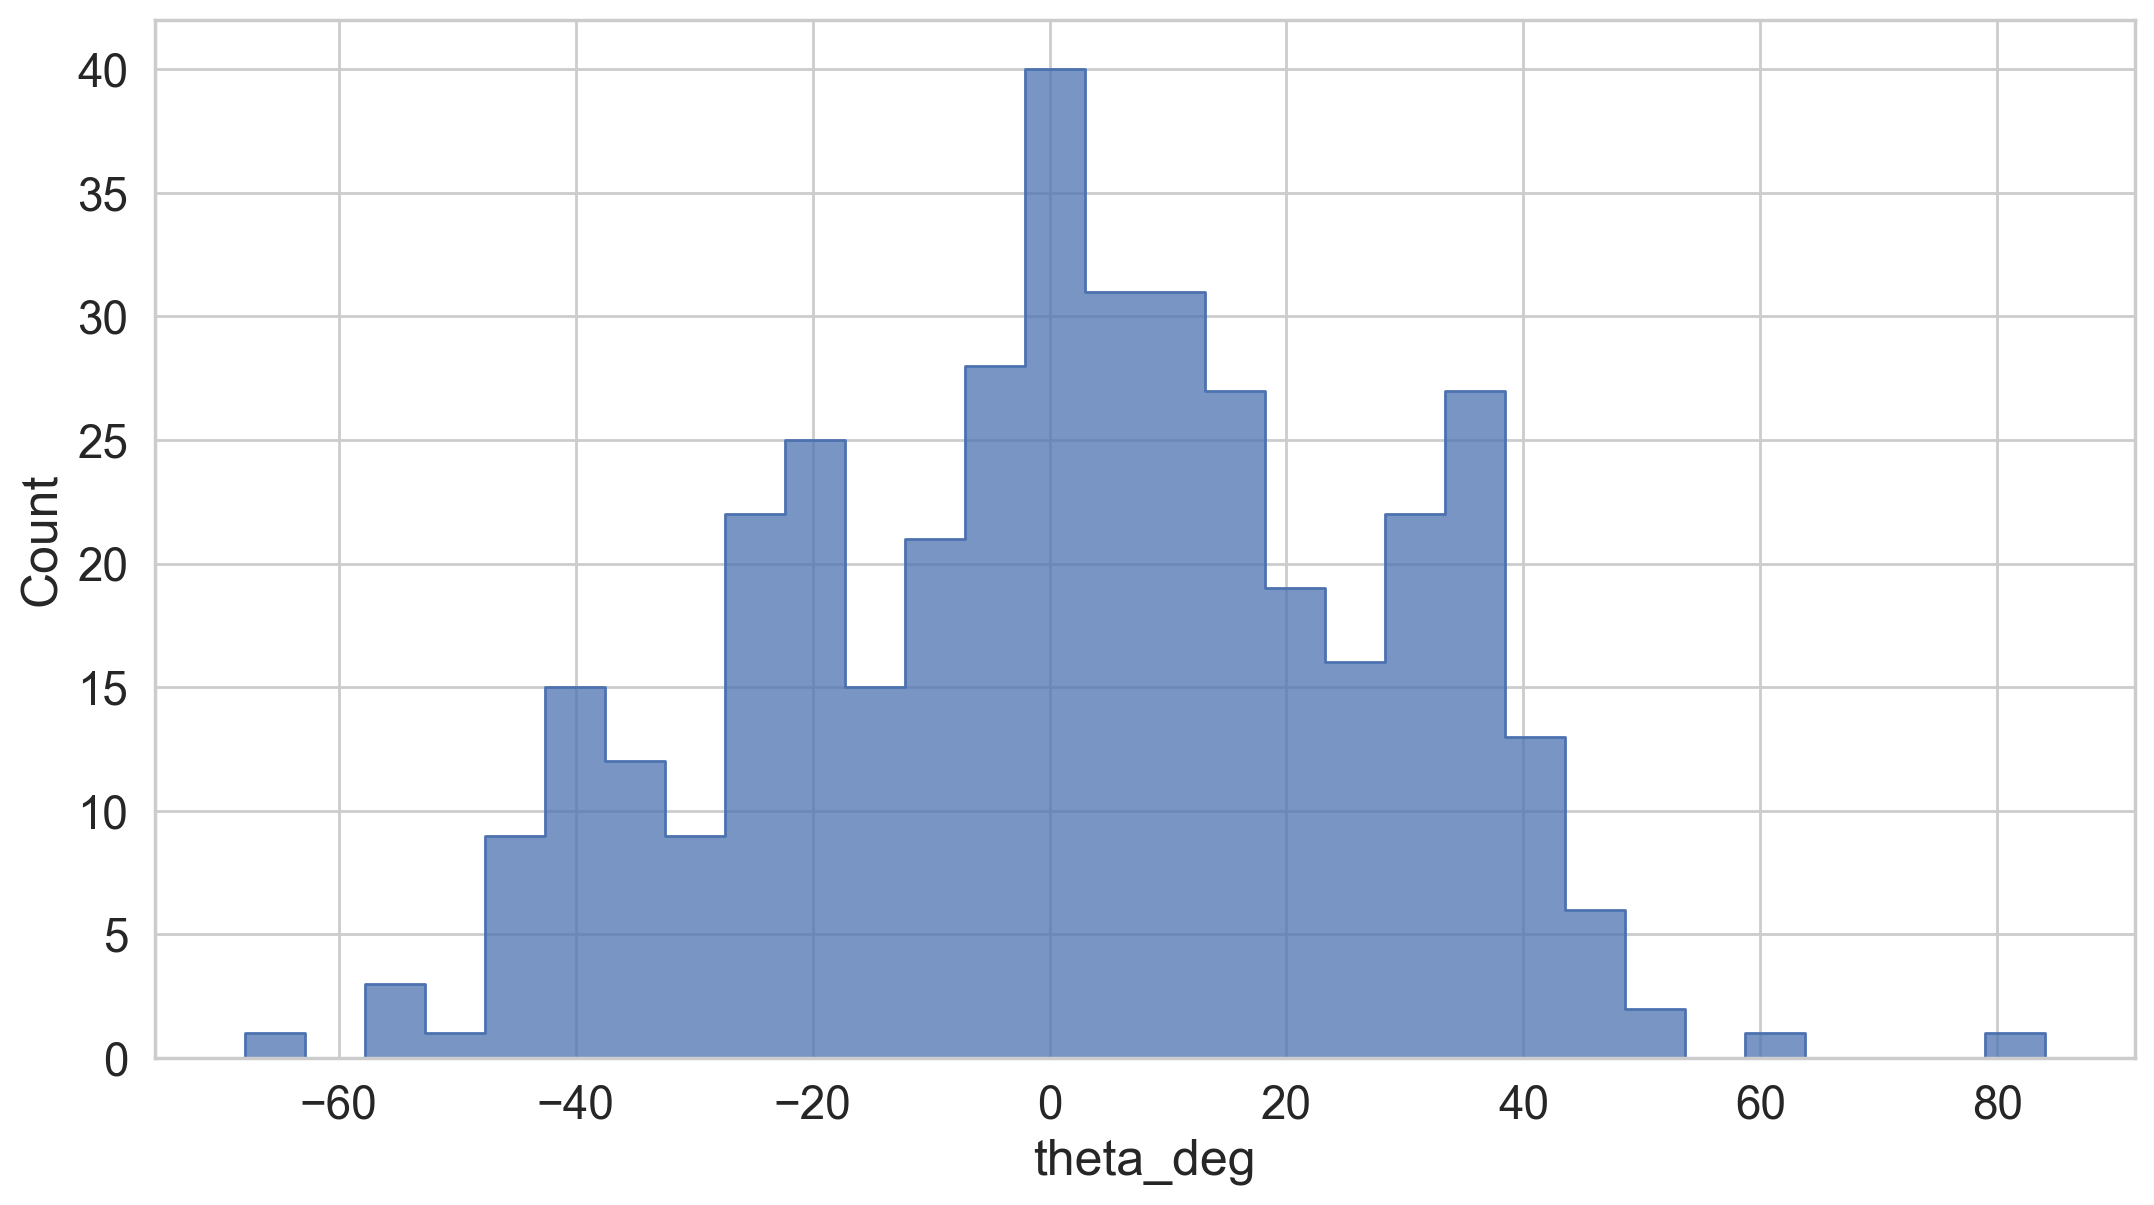

In [30]:
g = fovea.sns.histplot(
    data=gaussian_df,
    x='theta_deg',
    bins=30,
    element='step'  # Use step plots for clarity
)


Interpretation:

* θ=0: The major axis is aligned with the x-axis.
* θ=π/2: The major axis is aligned with the y-axis.
* θ=π/4: The major axis is at a 45° angle.


Voilà